## 0. imports



In [30]:
from pathlib import Path
from collections import Counter
import copy
import json
import math
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import ks_2samp

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_context("notebook")

RANDOM_STATE = 63
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

START_YEAR = 2014
END_YEAR = 2024
LABELED_SHARE = 0.10

FAST_MODE = False
MAX_PSEUDO_ROUNDS = 5 if FAST_MODE else 8
MAX_PSEUDO_PER_ROUND = 300 if FAST_MODE else 800
ACTIVE_ROUNDS = 3 if FAST_MODE else 8
ACTIVE_BATCH_SIZE = 20

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Full experiment mode:", not FAST_MODE)

Output directory: /kaggle/working
Full experiment mode: True


## 1. Data loading and inspection


In [31]:
from pathlib import Path

EXPECTED_FILES = {
    "races": "races.csv",
    "pit_stops": "pit_stops.csv",
    "lap_times": "lap_times.csv",
    "results": "results.csv",
    "driver_standings": "driver_standings.csv",
    "constructor_standings": "constructor_standings.csv",
    "constructors": "constructors.csv",
    "circuits": "circuits.csv",
}

INPUT_ROOT = Path("/kaggle/input")


def find_csv(filename):
    matches = list(INPUT_ROOT.rglob(filename))
    return matches[0]


file_paths = {
    name: find_csv(filename)
    for name, filename in EXPECTED_FILES.items()
}

for name, path in file_paths.items():
    print(f"{name} -> {path}")

races -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
pit_stops -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
lap_times -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
results -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/results.csv
driver_standings -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
constructor_standings -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
constructors -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
circuits -> /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/circuits.csv


In [32]:
def load_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, na_values=[r"\N", "NULL", "null", ""])


data = {name: load_csv(path) for name, path in file_paths.items()}

for name, df in data.items():
    print("=" * 90)
    print(f"{name}: shape={df.shape}")
    display(df.head(3))
    print("Dtypes:")
    display(df.dtypes.rename("dtype").to_frame().T)
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing.gt(0)].head(12).rename("missing_count").to_frame())

races: shape=(1125, 18)


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dtypes:


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
dtype,int64,int64,int64,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object


,missing_count
sprint_time,1110
sprint_date,1107
fp3_time,1072
quali_time,1057
fp2_time,1057
fp1_time,1057
fp3_date,1053
quali_date,1035
fp2_date,1035
fp1_date,1035


...

circuits: shape=(77, 9)


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...


Dtypes:


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
dtype,int64,object,object,object,object,float64,float64,int64,object


,missing_count


### Key relational IDs

The principal joins used below are:

- `raceId`: races, results, pit stops, lap times, and standings
- `driverId`: results, pit stops, lap times, and driver standings
- `constructorId`: results, constructors, and constructor standings
- `circuitId`: races and circuits

The race table supplies `year` and `round`, which are also used to shift championship standings to the values available **before** each race.

## 2. Cleaning and 2014–2024 filtering

In [33]:
races = data["races"].copy()
pit_stops = data["pit_stops"].copy()
lap_times = data["lap_times"].copy()
results = data["results"].copy()
driver_standings = data["driver_standings"].copy()
constructor_standings = data["constructor_standings"].copy()
constructors = data["constructors"].copy()
circuits = data["circuits"].copy()

numeric_columns = {
    "races": ["raceId", "year", "round", "circuitId"],
    "pit_stops": ["raceId", "driverId", "stop", "lap", "milliseconds"],
    "lap_times": ["raceId", "driverId", "lap", "position", "milliseconds"],
    "results": ["raceId", "driverId", "constructorId", "grid", "positionOrder", "points", "laps"],
    "driver_standings": ["raceId", "driverId", "points", "position", "wins"],
    "constructor_standings": ["raceId", "constructorId", "points", "position", "wins"],
    "constructors": ["constructorId"],
    "circuits": ["circuitId"],
}

frames = {
    "races": races,
    "pit_stops": pit_stops,
    "lap_times": lap_times,
    "results": results,
    "driver_standings": driver_standings,
    "constructor_standings": constructor_standings,
    "constructors": constructors,
    "circuits": circuits,
}

for frame_name, columns in numeric_columns.items():
    frame = frames[frame_name]
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

race_ids = races.loc[races["year"].between(START_YEAR, END_YEAR), "raceId"].dropna().astype(int)
race_id_set = set(race_ids)

races_era = races[races["raceId"].isin(race_id_set)].copy()
pit_stops_era = pit_stops[pit_stops["raceId"].isin(race_id_set)].copy()
lap_times_era = lap_times[lap_times["raceId"].isin(race_id_set)].copy()
results_era = results[results["raceId"].isin(race_id_set)].copy()

print(f"Races in {START_YEAR}–{END_YEAR}: {len(races_era):,}")
print(f"Pit stops in era: {len(pit_stops_era):,}")
print(f"Lap-time rows in era: {len(lap_times_era):,}")
print(f"Result rows in era: {len(results_era):,}")
print("Year range found:", int(races_era["year"].min()), "to", int(races_era["year"].max()))

Races in 2014–2024: 228
Pit stops in era: 8,360
Lap-time rows in era: 248,144
Result rows in era: 4,626
Year range found: 2014 to 2024


## 3. Championship points available before each race

Standings files contain cumulative points **after** a race. Within each season and competitor, shifting the points by one row gives the championship total available before the next race. Round 1 receives zero points.

In [34]:
race_order = races[["raceId", "year", "round"]].copy()

driver_points_pre = (
    driver_standings
    .merge(race_order, on="raceId", how="inner")
    .sort_values(["year", "driverId", "round", "raceId"])
)
driver_points_pre["driver_points_before"] = (
    driver_points_pre.groupby(["year", "driverId"])["points"].shift(1).fillna(0)
)
driver_points_pre = driver_points_pre[["raceId", "driverId", "driver_points_before"]]

constructor_points_pre = (
    constructor_standings
    .merge(race_order, on="raceId", how="inner")
    .sort_values(["year", "constructorId", "round", "raceId"])
)
constructor_points_pre["constructor_points_before"] = (
    constructor_points_pre.groupby(["year", "constructorId"])["points"].shift(1).fillna(0)
)
constructor_points_pre = constructor_points_pre[
    ["raceId", "constructorId", "constructor_points_before"]
]

display(driver_points_pre.head())
display(constructor_points_pre.head())

,raceId,driverId,driver_points_before
27129,834,427,0.0
27192,835,427,0.0
27246,836,427,0.0
27513,837,427,0.0
27377,838,427,0.0


,raceId,constructorId,constructor_points_before
9388,765,6,0.0
9381,766,6,6.0
9385,767,6,12.0
9367,768,6,14.0
9350,769,6,14.0


## 4. Lap-level feature engineering


In [35]:
laps = lap_times_era[
    ["raceId", "driverId", "lap", "position", "milliseconds"]
].dropna(subset=["raceId", "driverId", "lap", "milliseconds"]).copy()

laps[["raceId", "driverId", "lap", "position"]] = laps[
    ["raceId", "driverId", "lap", "position"]
].astype(int)
laps["milliseconds"] = pd.to_numeric(laps["milliseconds"], errors="coerce")
laps = laps.dropna(subset=["milliseconds"])
laps = laps.sort_values(["raceId", "driverId", "lap"]).reset_index(drop=True)

lap_driver_group = laps.groupby(["raceId", "driverId"], sort=False)

laps["personal_best_prior_ms"] = lap_driver_group["milliseconds"].transform(
    lambda s: s.shift(1).cummin()
)
laps["recent3_prior_mean_ms"] = lap_driver_group["milliseconds"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)

laps["personal_best_prior_ms"] = laps["personal_best_prior_ms"].fillna(laps["milliseconds"])
laps["recent3_prior_mean_ms"] = laps["recent3_prior_mean_ms"].fillna(laps["milliseconds"])

laps["lap_time_delta"] = laps["milliseconds"] - laps["personal_best_prior_ms"]
laps["recent_pace_delta"] = laps["recent3_prior_mean_ms"] - laps["personal_best_prior_ms"]
laps["cumulative_race_time_ms"] = lap_driver_group["milliseconds"].cumsum()

laps = laps.sort_values(["raceId", "lap", "position", "driverId"]).reset_index(drop=True)
race_lap_group = laps.groupby(["raceId", "lap"], sort=False)

cum_ahead = race_lap_group["cumulative_race_time_ms"].shift(1)
cum_behind = race_lap_group["cumulative_race_time_ms"].shift(-1)

laps["approx_gap_ahead"] = (
    (laps["cumulative_race_time_ms"] - cum_ahead) / 1000.0
).where(lambda s: s.ge(0)).clip(upper=180)

laps["approx_gap_behind"] = (
    (cum_behind - laps["cumulative_race_time_ms"]) / 1000.0
).where(lambda s: s.ge(0)).clip(upper=180)

lap_context = (
    laps.groupby(["raceId", "lap"], as_index=False)
    .agg(
        median_lap_ms=("milliseconds", "median"),
        drivers_on_lap=("driverId", "nunique"),
    )
    .sort_values(["raceId", "lap"])
)
lap_context["rolling_baseline_ms"] = lap_context.groupby("raceId")["median_lap_ms"].transform(
    lambda s: s.shift(1).rolling(5, min_periods=3).median()
)

laps = laps.merge(lap_context, on=["raceId", "lap"], how="left", validate="many_to_one")
laps["driver_slow_vs_baseline"] = (
    laps["milliseconds"] > 1.15 * laps["rolling_baseline_ms"]
).astype(float)
laps["slow_driver_share"] = laps.groupby(["raceId", "lap"])[
    "driver_slow_vs_baseline"
].transform("mean")

laps["safety_car_likely"] = (
    (laps["drivers_on_lap"] >= 5)
    & (laps["median_lap_ms"] > 1.15 * laps["rolling_baseline_ms"])
    & (laps["slow_driver_share"] >= 0.50)
).astype(int)

race_total_laps = (
    laps.groupby("raceId", as_index=False)["lap"]
    .max()
    .rename(columns={"lap": "race_total_laps"})
)

pit_lap_features = laps[
    [
        "raceId",
        "driverId",
        "lap",
        "position",
        "milliseconds",
        "lap_time_delta",
        "recent_pace_delta",
        "approx_gap_ahead",
        "approx_gap_behind",
        "safety_car_likely",
    ]
].rename(
    columns={
        "position": "current_position",
        "milliseconds": "pit_lap_time_ms",
    }
)

print("Pit-lap feature rows:", pit_lap_features.shape)
display(pit_lap_features.head())

Pit-lap feature rows: (248144, 10)


,raceId,driverId,lap,current_position,pit_lap_time_ms,lap_time_delta,recent_pace_delta,approx_gap_ahead,approx_gap_behind,safety_car_likely
0,900,3,1,1,102038,0.0,0.0,NaN,1.511,0
1,900,817,1,2,103549,0.0,0.0,1.511,1.853,0
2,900,825,1,3,105402,0.0,0.0,1.853,0.726,0
3,900,1,1,4,106128,0.0,0.0,0.726,0.858,0
4,900,807,1,5,106986,0.0,0.0,0.858,1.280,0


## 5. Build the pit-stop-level feature matrix

In [36]:
pits = pit_stops_era.copy()
pits = pits.dropna(subset=["raceId", "driverId", "lap"]).copy()
pits[["raceId", "driverId", "lap", "stop"]] = pits[
    ["raceId", "driverId", "lap", "stop"]
].astype(int)
pits["milliseconds"] = pd.to_numeric(pits["milliseconds"], errors="coerce")
pits = pits.sort_values(["raceId", "driverId", "lap", "stop"]).reset_index(drop=True)

previous_pit_lap = pits.groupby(["raceId", "driverId"])["lap"].shift(1)
pits["laps_since_last_pit"] = pits["lap"] - previous_pit_lap.fillna(0)

feature_df = pits.merge(
    pit_lap_features,
    on=["raceId", "driverId", "lap"],
    how="left",
    validate="many_to_one",
)
feature_df = feature_df.merge(race_total_laps, on="raceId", how="left", validate="many_to_one")

race_meta = races_era[
    ["raceId", "year", "round", "circuitId", "name", "date"]
].rename(columns={"name": "race_name"})
feature_df = feature_df.merge(race_meta, on="raceId", how="left", validate="many_to_one")

result_meta = results_era[
    ["raceId", "driverId", "constructorId", "grid", "positionOrder"]
].drop_duplicates(["raceId", "driverId"])
feature_df = feature_df.merge(
    result_meta,
    on=["raceId", "driverId"],
    how="left",
    validate="many_to_one",
)

constructor_meta = constructors[["constructorId", "name"]].rename(
    columns={"name": "constructor_name"}
)
circuit_meta = circuits[["circuitId", "name"]].rename(columns={"name": "circuit_name"})

feature_df = feature_df.merge(
    constructor_meta, on="constructorId", how="left", validate="many_to_one"
)
feature_df = feature_df.merge(
    circuit_meta, on="circuitId", how="left", validate="many_to_one"
)
feature_df = feature_df.merge(
    driver_points_pre, on=["raceId", "driverId"], how="left", validate="many_to_one"
)
feature_df = feature_df.merge(
    constructor_points_pre,
    on=["raceId", "constructorId"],
    how="left",
    validate="many_to_one",
)

feature_df = feature_df.rename(
    columns={
        "lap": "pit_lap",
        "stop": "stop_number",
        "milliseconds_x": "stop_duration_ms",
    }
)

if "stop_duration_ms" not in feature_df.columns and "milliseconds" in feature_df.columns:
    feature_df = feature_df.rename(columns={"milliseconds": "stop_duration_ms"})

feature_df["driver_points_before"] = feature_df["driver_points_before"].fillna(0)
feature_df["constructor_points_before"] = feature_df["constructor_points_before"].fillna(0)
feature_df["laps_remaining"] = (
    feature_df["race_total_laps"] - feature_df["pit_lap"]
).clip(lower=0)
feature_df["race_progress"] = (
    feature_df["pit_lap"] / feature_df["race_total_laps"].replace(0, np.nan)
).clip(0, 1)
feature_df["position_change_from_grid"] = (
    feature_df["grid"] - feature_df["current_position"]
)

gap_a = feature_df["approx_gap_ahead"].clip(lower=0)
gap_b = feature_df["approx_gap_behind"].clip(lower=0)
feature_df["pressure_index"] = 1 / (1 + gap_a) + 1 / (1 + gap_b)

feature_df["row_id"] = np.arange(len(feature_df))

preferred_order = [
    "row_id",
    "raceId",
    "driverId",
    "constructorId",
    "circuitId",
    "year",
    "round",
    "race_name",
    "circuit_name",
    "constructor_name",
    "date",
    "stop_number",
    "pit_lap",
    "stop_duration_ms",
    "pit_lap_time_ms",
    "grid",
    "current_position",
    "positionOrder",
    "driver_points_before",
    "constructor_points_before",
    "lap_time_delta",
    "recent_pace_delta",
    "laps_since_last_pit",
    "race_total_laps",
    "laps_remaining",
    "race_progress",
    "approx_gap_ahead",
    "approx_gap_behind",
    "pressure_index",
    "position_change_from_grid",
    "safety_car_likely",
]
preferred_order = [c for c in preferred_order if c in feature_df.columns]
feature_df = feature_df[preferred_order].copy()

print("Feature-matrix shape:", feature_df.shape)
print("Rows with missing required lap features:")
required_lap_features = [
    "lap_time_delta",
    "laps_since_last_pit",
    "laps_remaining",
    "approx_gap_ahead",
    "approx_gap_behind",
    "safety_car_likely",
]
display(feature_df[required_lap_features].isna().sum().rename("missing").to_frame())
display(feature_df.head())

Feature-matrix shape: (8360, 31)
Rows with missing required lap features:


,missing
lap_time_delta,0
laps_since_last_pit,0
laps_remaining,0
approx_gap_ahead,514
approx_gap_behind,594
safety_car_likely,0


,row_id,raceId,driverId,constructorId,circuitId,year,round,race_name,circuit_name,constructor_name,date,stop_number,pit_lap,stop_duration_ms,pit_lap_time_ms,grid,current_position,positionOrder,driver_points_before,constructor_points_before,lap_time_delta,recent_pace_delta,laps_since_last_pit,race_total_laps,laps_remaining,race_progress,approx_gap_ahead,approx_gap_behind,pressure_index,position_change_from_grid,safety_car_likely
0,0,900,3,131,1,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Mercedes,2014-03-16,1,12,24331,134269,3,1,1,0.0,0.0,40052.0,371.666667,12.0,57,45,0.210526,NaN,8.677,NaN,2,1
1,1,900,3,131,1,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Mercedes,2014-03-16,2,38,23673,115194,3,1,1,0.0,0.0,22716.0,2067.000000,26.0,57,19,0.666667,NaN,23.472,NaN,2,0
2,2,900,4,6,1,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Ferrari,2014-03-16,1,12,22887,139525,5,5,4,0.0,0.0,43891.0,1387.333333,12.0,57,45,0.210526,4.515,7.044,0.305640,0,1
3,3,900,4,6,1,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Ferrari,2014-03-16,2,35,21978,112828,5,7,4,0.0,0.0,18751.0,1328.333333,23.0,57,22,0.614035,7.735,3.526,0.335428,-2,0
4,4,900,8,6,1,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit,Ferrari,2014-03-16,1,12,25543,145964,11,8,7,0.0,0.0,50832.0,1649.666667,12.0,57,45,0.210526,1.939,6.273,0.477747,3,1


## 6. Rule-based strategy labeling


In [37]:
def percentile_score(series: pd.Series, higher_is_more: bool = True) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    median = x.median()
    if pd.isna(median):
        median = 0.0
    x = x.fillna(median)
    rank = x.rank(method="average", pct=True)
    return rank if higher_is_more else 1.0 - rank


def make_strategy_labels(
    df: pd.DataFrame,
    emergency_share: float = 0.10,
    undercut_share: float = 0.15,
    overcut_share: float = 0.06,
) -> pd.DataFrame:
    out = df.copy()

    stop_log = np.log1p(pd.to_numeric(out["stop_duration_ms"], errors="coerce").clip(lower=0))

    out["emergency_rule_score"] = (
        3.0 * out["safety_car_likely"].fillna(0)
        + 1.35 * percentile_score(out["lap_time_delta"], True)
        + 0.90 * percentile_score(stop_log, True)
        + 0.45 * percentile_score(out["recent_pace_delta"], True)
    )

    out["undercut_rule_score"] = (
        1.80 * percentile_score(out["approx_gap_ahead"], False)
        + 0.90 * percentile_score(out["laps_remaining"], True)
        + 0.75 * percentile_score(out["laps_since_last_pit"], False)
        + 0.45 * percentile_score(out["pressure_index"], True)
    )

    out["overcut_rule_score"] = (
        1.55 * percentile_score(out["laps_since_last_pit"], True)
        + 0.85 * percentile_score(out["recent_pace_delta"], False)
        + 0.65 * percentile_score(out["approx_gap_behind"], True)
        + 0.35 * percentile_score(out["race_progress"], True)
    )

    labels = pd.Series("Standard", index=out.index, dtype="object")
    available = pd.Series(True, index=out.index)
    n = len(out)

    target_counts = {
        "Emergency": int(round(n * emergency_share)),
        "Undercut": int(round(n * undercut_share)),
        "Overcut": int(round(n * overcut_share)),
    }

    for label, score_column in [
        ("Emergency", "emergency_rule_score"),
        ("Undercut", "undercut_rule_score"),
        ("Overcut", "overcut_rule_score"),
    ]:
        candidate_scores = out.loc[available, score_column]
        selected = candidate_scores.nlargest(min(target_counts[label], len(candidate_scores))).index
        labels.loc[selected] = label
        available.loc[selected] = False

    out["strategy"] = labels
    return out


scored_feature_df = make_strategy_labels(feature_df)
rule_score_columns = [
    "emergency_rule_score",
    "undercut_rule_score",
    "overcut_rule_score",
]
full_labeled_df = scored_feature_df.drop(columns=rule_score_columns)

class_distribution = (
    full_labeled_df["strategy"].value_counts()
    .rename("count")
    .to_frame()
    .assign(percent=lambda d: 100 * d["count"] / d["count"].sum())
)
display(class_distribution)

san_check_features = [
    "stop_duration_ms",
    "lap_time_delta",
    "laps_since_last_pit",
    "laps_remaining",
    "approx_gap_ahead",
    "approx_gap_behind",
    "safety_car_likely",
    "recent_pace_delta",
]
display(full_labeled_df.groupby("strategy")[san_check_features].median().round(2))

,count,percent
strategy,,
Standard,5768,68.995215
Undercut,1254,15.000000
Emergency,836,10.000000
Overcut,502,6.004785


,stop_duration_ms,lap_time_delta,laps_since_last_pit,laps_remaining,approx_gap_ahead,approx_gap_behind,safety_car_likely,recent_pace_delta
strategy,,,,,,,,
Emergency,30475.5,45123.0,9.0,31.0,3.31,3.39,1.0,8498.33
Overcut,23190.5,4742.5,32.0,23.0,5.32,12.06,0.0,281.50
Standard,23826.0,4999.5,18.0,33.0,4.14,3.46,0.0,799.50
Undercut,23413.5,4407.5,8.0,52.0,0.76,1.44,0.0,500.67


## 7. Stratified split into `labeled.csv` and `unlabeled.csv`

In [38]:
labeled_df, oracle_unlabeled_df = train_test_split(
    full_labeled_df,
    test_size=1 - LABELED_SHARE,
    stratify=full_labeled_df["strategy"],
    random_state=RANDOM_STATE,
)

labeled_df = labeled_df.sort_values("row_id").reset_index(drop=True)
oracle_unlabeled_df = oracle_unlabeled_df.sort_values("row_id").reset_index(drop=True)
unlabeled_df = oracle_unlabeled_df.drop(columns="strategy").copy()

labeled_path = OUTPUT_DIR / "labeled.csv"
unlabeled_path = OUTPUT_DIR / "unlabeled.csv"
labeled_df.to_csv(labeled_path, index=False)
unlabeled_df.to_csv(unlabeled_path, index=False)

print("labeled.csv shape:", labeled_df.shape)
print("unlabeled.csv shape:", unlabeled_df.shape)
print("Saved:", labeled_path)
print("Saved:", unlabeled_path)

print("\nLabeled class counts:")
display(labeled_df["strategy"].value_counts().rename("count").to_frame())

print("\nThree labeled rows:")
display(labeled_df.sample(3, random_state=RANDOM_STATE))
print("\nThree unlabeled rows:")
display(unlabeled_df.sample(3, random_state=RANDOM_STATE))

split_proportions = pd.concat(
    {
        "Full pool": full_labeled_df["strategy"].value_counts(normalize=True),
        "Labeled 10%": labeled_df["strategy"].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)
split_proportions["absolute_difference"] = (
    split_proportions["Full pool"] - split_proportions["Labeled 10%"]
).abs()
display((100 * split_proportions).round(2))

labeled.csv shape: (836, 32)
unlabeled.csv shape: (7524, 31)
Saved: /kaggle/working/labeled.csv
Saved: /kaggle/working/unlabeled.csv

Labeled class counts:


,count
strategy,
Standard,577
Undercut,125
Emergency,84
Overcut,50



Three labeled rows:


,row_id,raceId,driverId,constructorId,circuitId,year,round,race_name,circuit_name,constructor_name,date,stop_number,pit_lap,stop_duration_ms,pit_lap_time_ms,grid,current_position,positionOrder,driver_points_before,constructor_points_before,lap_time_delta,recent_pace_delta,laps_since_last_pit,race_total_laps,laps_remaining,race_progress,approx_gap_ahead,approx_gap_behind,pressure_index,position_change_from_grid,safety_car_likely,strategy
262,2518,968,13,3,24,2016,21,Abu Dhabi Grand Prix,Yas Marina Circuit,Williams,2016-11-27,2,30,21539,109282,10,7,9,51.0,136.0,2212.0,454.333333,22.0,55,25,0.545455,12.708,0.889,0.602331,3,0,Standard
352,3551,1000,838,1,11,2018,12,Hungarian Grand Prix,Hungaroring,McLaren,2018-07-29,1,40,21732,85839,16,7,18,8.0,48.0,2470.0,100.000000,40.0,70,30,0.571429,10.741,1.283,0.523192,9,0,Overcut
416,4126,1020,846,1,10,2019,11,German Grand Prix,Hockenheimring,McLaren,2019-07-28,2,25,20242,99025,19,14,18,22.0,60.0,7944.0,3038.000000,19.0,64,39,0.390625,1.666,6.961,0.500706,5,0,Standard



Three unlabeled rows:


,row_id,raceId,driverId,constructorId,circuitId,year,round,race_name,circuit_name,constructor_name,date,stop_number,pit_lap,stop_duration_ms,pit_lap_time_ms,grid,current_position,positionOrder,driver_points_before,constructor_points_before,lap_time_delta,recent_pace_delta,laps_since_last_pit,race_total_laps,laps_remaining,race_progress,approx_gap_ahead,approx_gap_behind,pressure_index,position_change_from_grid,safety_car_likely
692,769,917,825,1,18,2014,18,Brazilian Grand Prix,Autódromo José Carlos Pace,McLaren,2014-11-09,1,7,23061,81676,7,4,9,53.0,147.0,4726.0,129.000000,7.0,71,64,0.098592,0.453,0.179,1.536408,3,0
3314,3677,1005,844,15,22,2018,17,Japanese Grand Prix,Suzuka Circuit,Sauber,2018-10-07,2,35,26672,100241,10,13,18,21.0,27.0,3801.0,826.666667,31.0,53,18,0.660377,0.199,4.458,1.017246,-3,0
1724,1921,956,8,6,70,2016,9,Austrian Grand Prix,Red Bull Ring,Ferrari,2016-07-03,2,28,21206,124776,4,5,3,81.0,177.0,54165.0,10715.333333,6.0,71,43,0.394366,2.786,1.163,0.726452,-1,1


,Full pool,Labeled 10%,absolute_difference
strategy,,,
Standard,69.0,69.02,0.02
Undercut,15.0,14.95,0.05
Emergency,10.0,10.05,0.05
Overcut,6.0,5.98,0.02


## 8. Exploratory data analysis



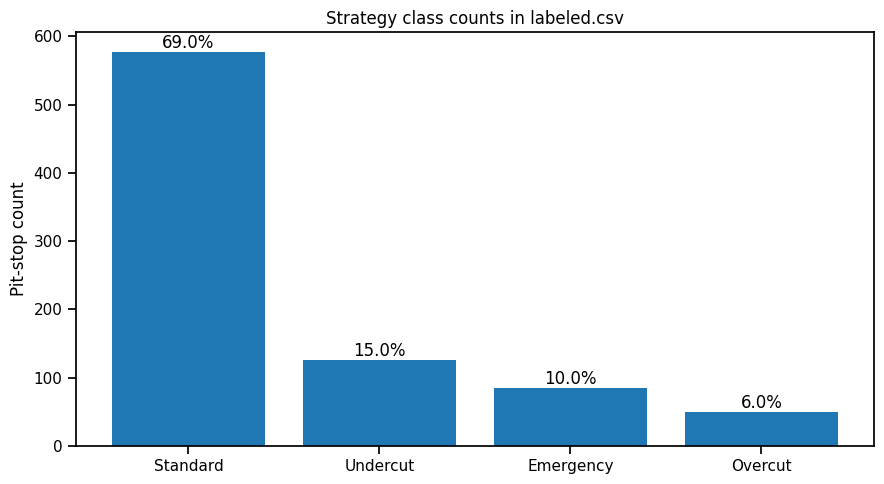

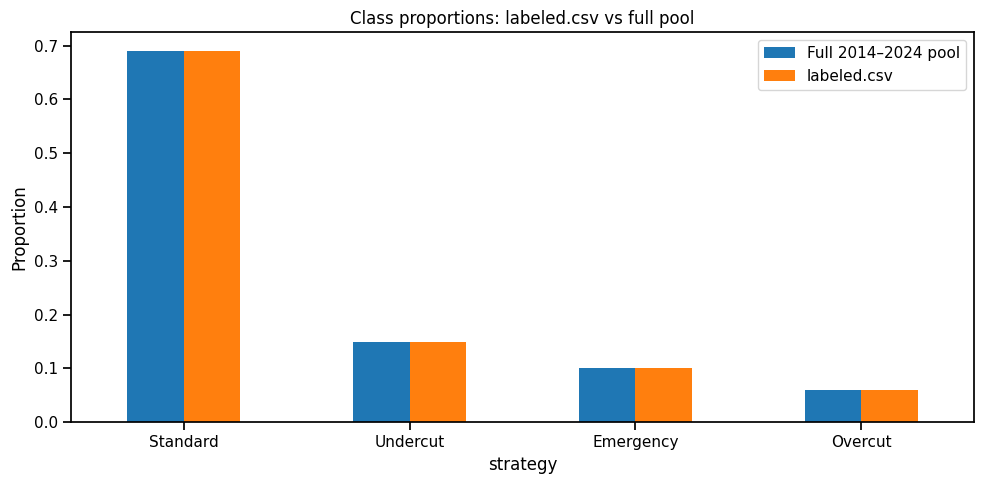

In [39]:
class_order = ["Standard", "Undercut", "Emergency", "Overcut"]
counts = labeled_df["strategy"].value_counts().reindex(class_order).fillna(0)
percentages = 100 * counts / counts.sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values)
ax.set_title("Strategy class counts in labeled.csv")
ax.set_ylabel("Pit-stop count")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

comparison = pd.concat(
    {
        "Full 2014–2024 pool": full_labeled_df["strategy"].value_counts(normalize=True),
        "labeled.csv": labeled_df["strategy"].value_counts(normalize=True),
    },
    axis=1,
).reindex(class_order).fillna(0)

comparison.plot(kind="bar", figsize=(10, 5))
plt.title("Class proportions: labeled.csv vs full pool")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

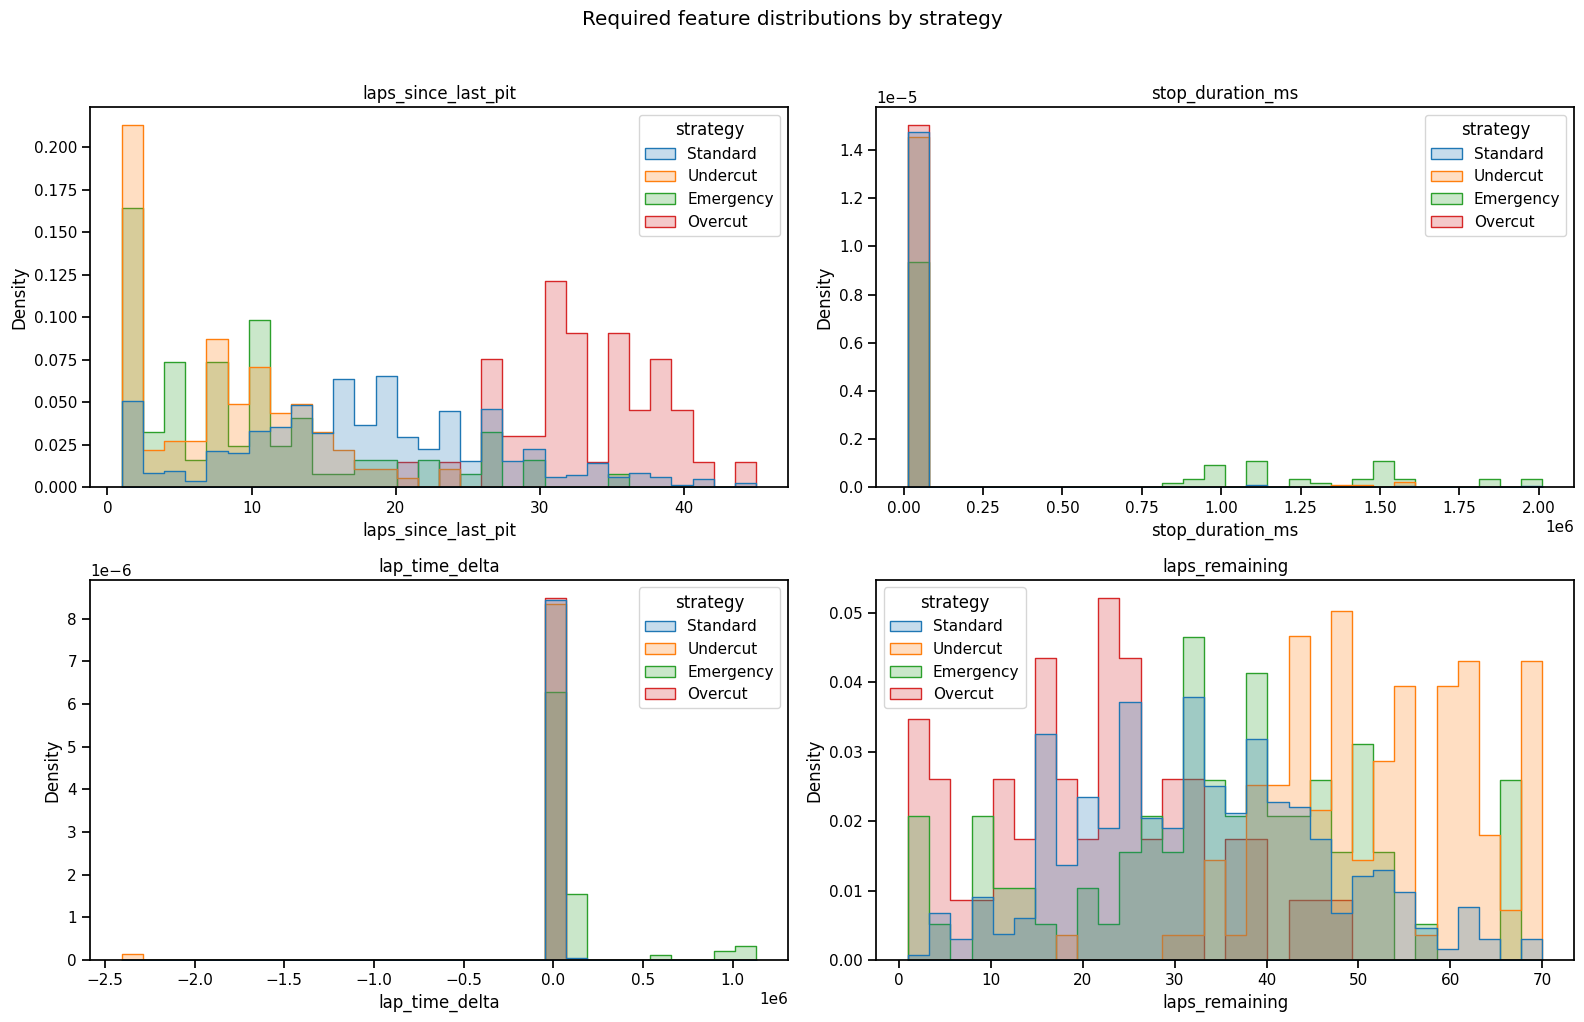

In [40]:
key_features = [
    "laps_since_last_pit",
    "stop_duration_ms",
    "lap_time_delta",
    "laps_remaining",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for feature, ax in zip(key_features, axes.ravel()):
    plot_data = labeled_df[[feature, "strategy"]].replace([np.inf, -np.inf], np.nan).dropna()
    upper = plot_data[feature].quantile(0.99)
    plot_data = plot_data[plot_data[feature] <= upper]
    sns.histplot(
        data=plot_data,
        x=feature,
        hue="strategy",
        hue_order=class_order,
        bins=30,
        element="step",
        stat="density",
        common_norm=False,
        alpha=0.25,
        ax=ax,
    )
    ax.set_title(feature)
plt.suptitle("Required feature distributions by strategy", y=1.02)
plt.tight_layout()
plt.show()

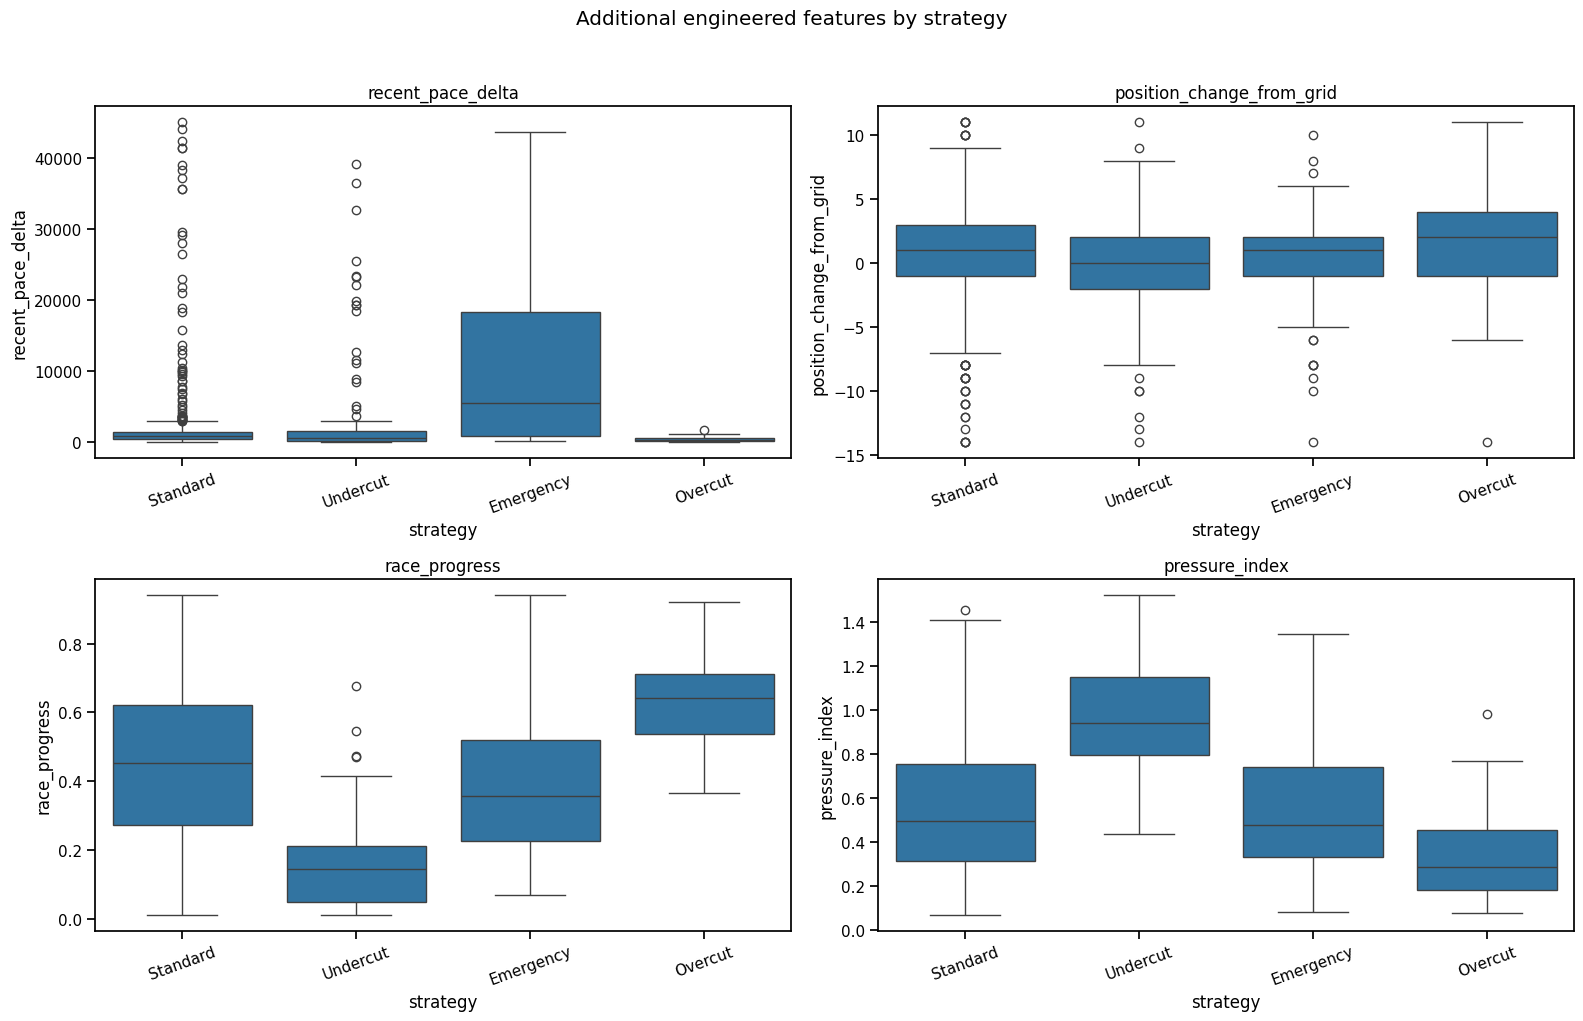

In [41]:
bonus_features = [
    "recent_pace_delta",
    "position_change_from_grid",
    "race_progress",
    "pressure_index",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for feature, ax in zip(bonus_features, axes.ravel()):
    plot_data = labeled_df[[feature, "strategy"]].replace([np.inf, -np.inf], np.nan).dropna()
    low, high = plot_data[feature].quantile([0.01, 0.99])
    plot_data = plot_data[plot_data[feature].between(low, high)]
    sns.boxplot(data=plot_data, x="strategy", y=feature, order=class_order, ax=ax)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Additional engineered features by strategy", y=1.02)
plt.tight_layout()
plt.show()

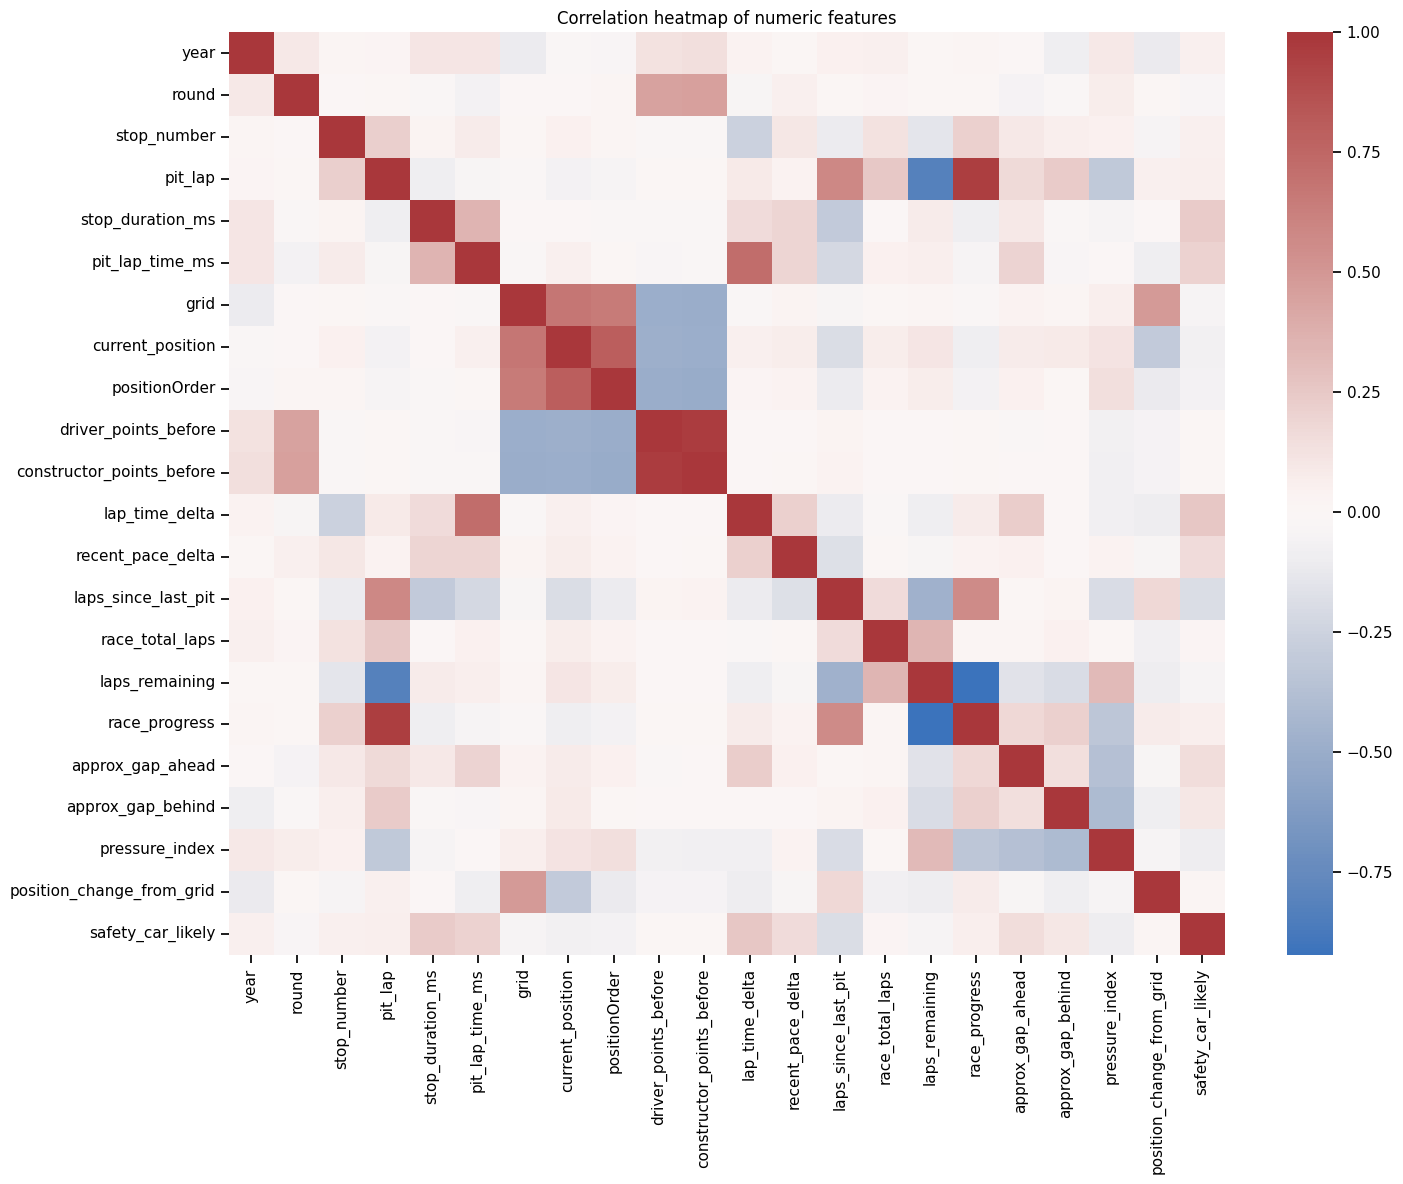

In [42]:
numeric_for_corr = [
    c for c in labeled_df.select_dtypes(include=np.number).columns
    if c not in {"row_id", "raceId", "driverId", "constructorId", "circuitId"}
]
corr = labeled_df[numeric_for_corr].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="vlag", center=0, square=False)
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.show()

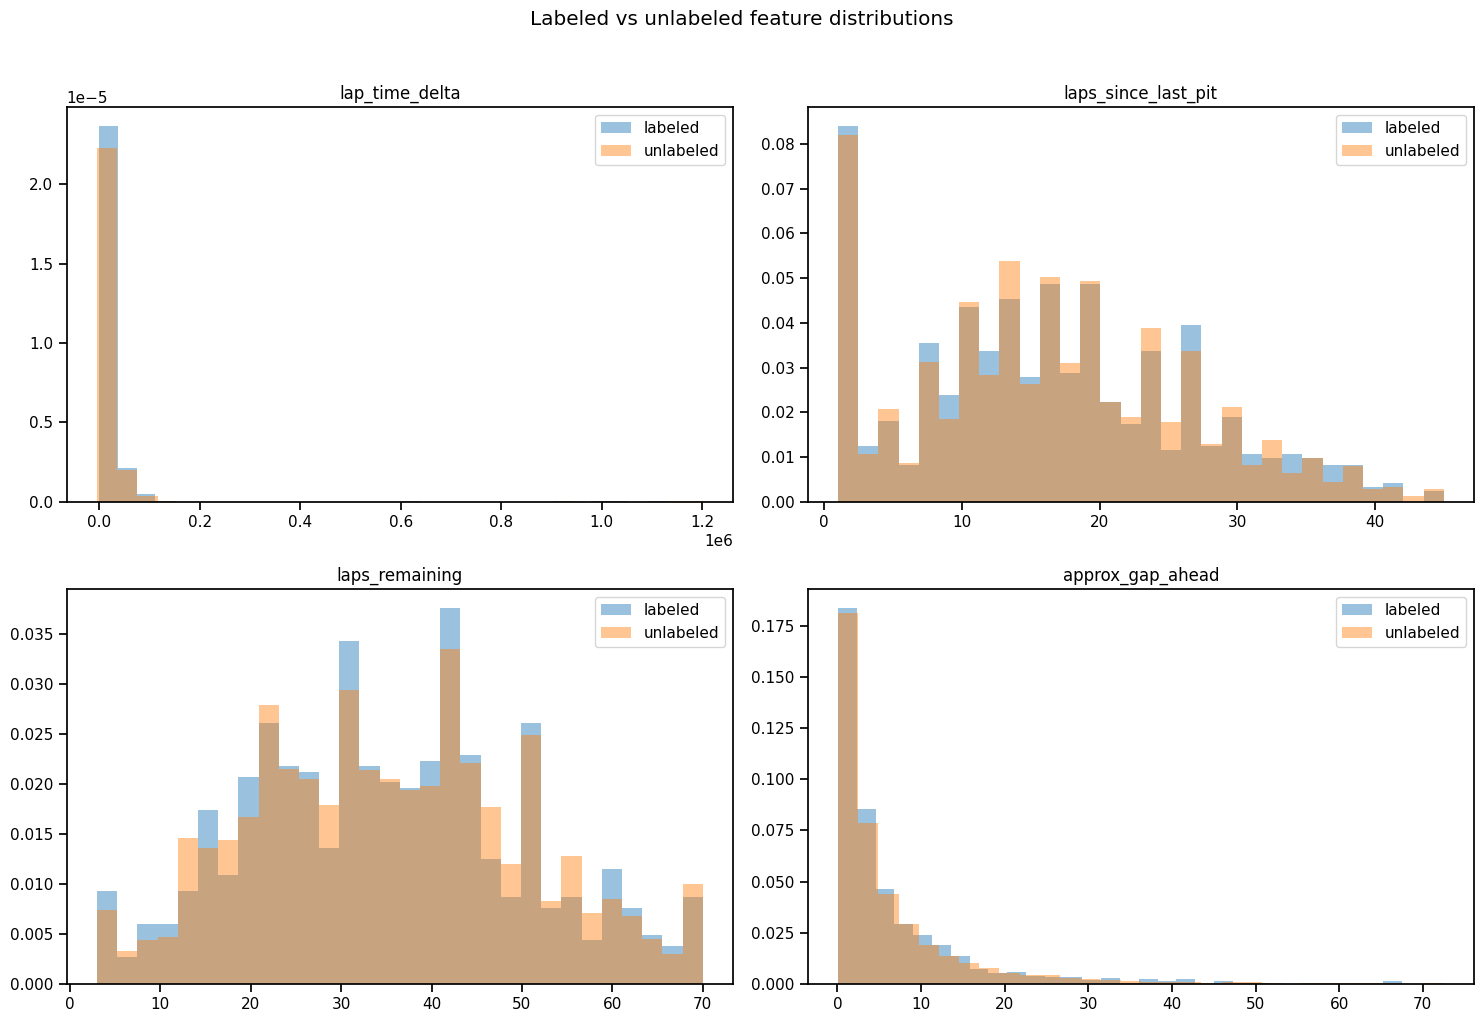

,feature,KS_statistic,p_value,p_above_0.05
5,recent_pace_delta,0.0284,0.5688,True
7,pressure_index,0.0286,0.6446,True
3,approx_gap_ahead,0.0256,0.7272,True
0,lap_time_delta,0.0233,0.8032,True
1,laps_since_last_pit,0.0213,0.8797,True
2,laps_remaining,0.0210,0.8887,True
4,approx_gap_behind,0.0209,0.9156,True
6,race_progress,0.0195,0.9319,True


In [43]:
split_check_features = [
    "lap_time_delta",
    "laps_since_last_pit",
    "laps_remaining",
    "approx_gap_ahead",
    "approx_gap_behind",
    "recent_pace_delta",
    "race_progress",
    "pressure_index",
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for feature, ax in zip(split_check_features[:4], axes.ravel()):
    left = labeled_df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    right = unlabeled_df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    combined = pd.concat([left, right])
    low, high = combined.quantile([0.01, 0.99])
    ax.hist(left[left.between(low, high)], bins=30, alpha=0.45, density=True, label="labeled")
    ax.hist(right[right.between(low, high)], bins=30, alpha=0.45, density=True, label="unlabeled")
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Labeled vs unlabeled feature distributions", y=1.02)
plt.tight_layout()
plt.show()

ks_rows = []
for feature in split_check_features:
    a = labeled_df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    b = unlabeled_df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    statistic, p_value = ks_2samp(a, b)
    ks_rows.append(
        {
            "feature": feature,
            "KS_statistic": statistic,
            "p_value": p_value,
            "p_above_0.05": p_value > 0.05,
        }
    )
ks_results = pd.DataFrame(ks_rows).sort_values("p_value")
display(ks_results.round(4))

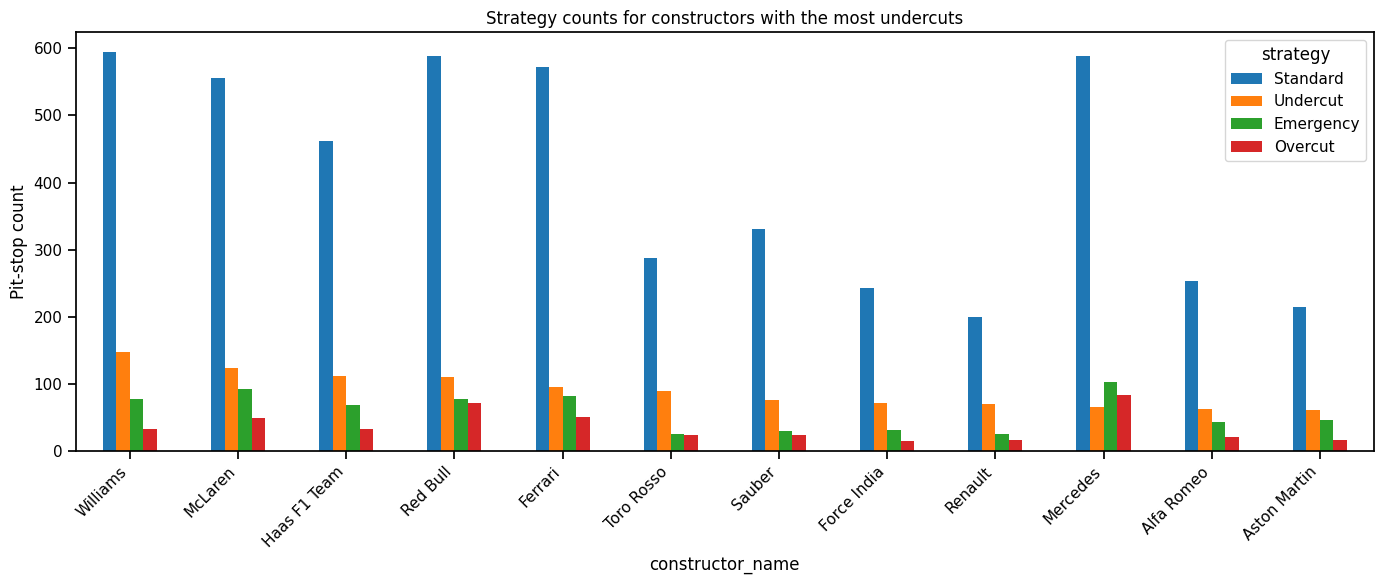

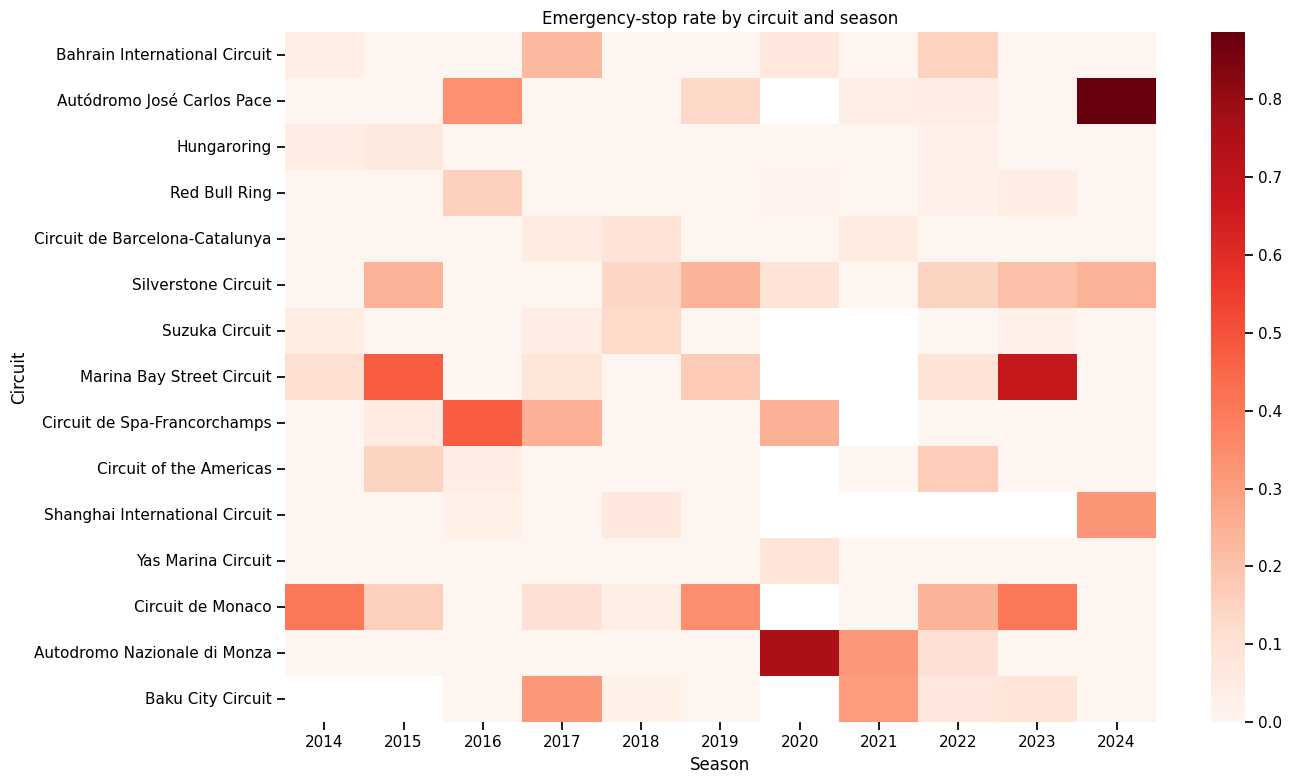

,mean_gap_ahead,pit_stops
circuit_name,,
Las Vegas Strip Street Circuit,3.49,70
Miami International Autodrome,4.04,73
Autódromo Internacional do Algarve,4.34,85
Jeddah Corniche Circuit,4.63,109
Red Bull Ring,5.24,464
Autodromo Nazionale di Monza,5.75,298
Shanghai International Circuit,5.99,338
Yas Marina Circuit,6.03,333
Hockenheimring,6.21,233


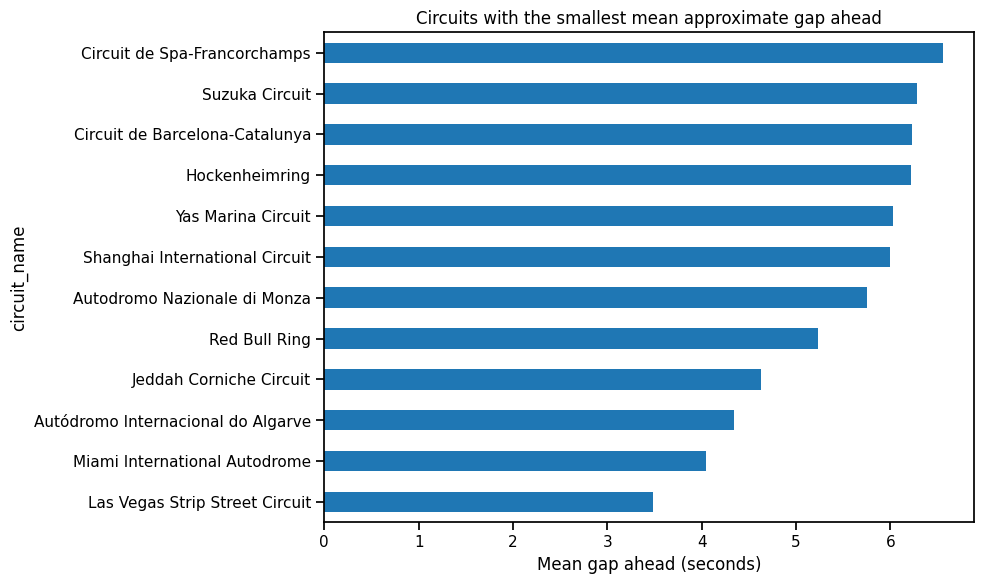

In [44]:
constructor_strategy = pd.crosstab(
    full_labeled_df["constructor_name"], full_labeled_df["strategy"]
)
for column in class_order:
    if column not in constructor_strategy:
        constructor_strategy[column] = 0

top_undercut_teams = constructor_strategy.sort_values("Undercut", ascending=False).head(12)
top_undercut_teams[class_order].plot(kind="bar", figsize=(14, 6))
plt.title("Strategy counts for constructors with the most undercuts")
plt.ylabel("Pit-stop count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

emergency_by_circuit_year = (
    full_labeled_df.assign(is_emergency=lambda d: (d["strategy"] == "Emergency").astype(int))
    .groupby(["circuit_name", "year"])["is_emergency"]
    .mean()
    .unstack(fill_value=np.nan)
)
top_circuits = full_labeled_df["circuit_name"].value_counts().head(15).index

plt.figure(figsize=(14, 8))
sns.heatmap(
    emergency_by_circuit_year.reindex(top_circuits),
    cmap="Reds",
    vmin=0,
    vmax=max(0.25, emergency_by_circuit_year.max().max()),
)
plt.title("Emergency-stop rate by circuit and season")
plt.xlabel("Season")
plt.ylabel("Circuit")
plt.tight_layout()
plt.show()

smallest_gap_circuits = (
    full_labeled_df.groupby("circuit_name")
    .agg(
        mean_gap_ahead=("approx_gap_ahead", "mean"),
        pit_stops=("row_id", "size"),
    )
    .query("pit_stops >= 30")
    .sort_values("mean_gap_ahead")
    .head(12)
)
display(smallest_gap_circuits.round(2))

smallest_gap_circuits.sort_values("mean_gap_ahead", ascending=True)["mean_gap_ahead"].plot(
    kind="barh", figsize=(10, 6)
)
plt.title("Circuits with the smallest mean approximate gap ahead")
plt.xlabel("Mean gap ahead (seconds)")
plt.tight_layout()
plt.show()

## 9. Supervised-learning baseline


In [45]:
numeric_features = [
    "year",
    "round",
    "stop_number",
    "pit_lap",
    "pit_lap_time_ms",
    "grid",
    "current_position",
    "driver_points_before",
    "constructor_points_before",
    "lap_time_delta",
    "recent_pace_delta",
    "laps_since_last_pit",
    "race_total_laps",
    "laps_remaining",
    "race_progress",
    "approx_gap_ahead",
    "approx_gap_behind",
    "pressure_index",
    "position_change_from_grid",
]
categorical_features = ["constructor_name", "circuit_name"]

numeric_features = [c for c in numeric_features if c in labeled_df.columns]
categorical_features = [c for c in categorical_features if c in labeled_df.columns]
feature_columns = numeric_features + categorical_features

assert "safety_car_likely" not in feature_columns
assert "stop_duration_ms" not in feature_columns

X = labeled_df[feature_columns].copy()
y = labeled_df["strategy"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Validation:", X_val.shape, y_val.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (668, 21) {'Standard': 461, 'Undercut': 100, 'Emergency': 67, 'Overcut': 40}
Validation: (84, 21) {'Standard': 58, 'Undercut': 13, 'Emergency': 8, 'Overcut': 5}
Test: (84, 21) {'Standard': 58, 'Undercut': 12, 'Emergency': 9, 'Overcut': 5}


In [46]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

rf_estimators = 120 if FAST_MODE else 300
gb_estimators = 80 if FAST_MODE else 180

model_templates = {
    "Logistic Regression": Pipeline(
        [
            ("preprocessor", clone(preprocessor)),
            (
                "model",
                LogisticRegression(
                    max_iter=2500,
                    class_weight="balanced",
                    C=0.7,
                    multi_class="auto",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("preprocessor", clone(preprocessor)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=rf_estimators,
                    max_depth=9,
                    min_samples_leaf=5,
                    max_features="sqrt",
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Gradient Boosting": Pipeline(
        [
            ("preprocessor", clone(preprocessor)),
            (
                "model",
                GradientBoostingClassifier(
                    n_estimators=gb_estimators,
                    learning_rate=0.05,
                    max_depth=3,
                    min_samples_leaf=6,
                    subsample=0.85,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}


def fit_named_model(model_name: str, X_fit: pd.DataFrame, y_fit: pd.Series) -> Pipeline:
    estimator = clone(model_templates[model_name])
    if model_name == "Gradient Boosting":
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_fit)
        estimator.fit(X_fit, y_fit, model__sample_weight=sample_weight)
    else:
        estimator.fit(X_fit, y_fit)
    return estimator


def metric_row(y_true, y_pred) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def evaluate_estimator(estimator: Pipeline, X_eval: pd.DataFrame, y_eval: pd.Series) -> dict:
    predictions = estimator.predict(X_eval)
    return metric_row(y_eval, predictions)

In [47]:
validation_rows = []
fitted_baselines = {}

for model_name in model_templates:
    fitted = fit_named_model(model_name, X_train, y_train)
    fitted_baselines[model_name] = fitted
    row = {"model": model_name, **evaluate_estimator(fitted, X_val, y_val)}
    validation_rows.append(row)

validation_results = pd.DataFrame(validation_rows).sort_values("macro_f1", ascending=False)
display(validation_results.round(4))

best_model_name = validation_results.iloc[0]["model"]
baseline_model = fitted_baselines[best_model_name]
print("Selected model by validation Macro F1:", best_model_name)

,model,accuracy,macro_precision,macro_recall,macro_f1
2,Gradient Boosting,0.8929,0.8205,0.9044,0.8576
1,Random Forest,0.8571,0.7489,0.8271,0.7789
0,Logistic Regression,0.6667,0.5810,0.8225,0.6365


Selected model by validation Macro F1: Gradient Boosting


Baseline test metrics


,accuracy,macro_precision,macro_recall,macro_f1
Gradient Boosting,0.881,0.8419,0.8865,0.8605


Per-class report


,precision,recall,f1-score,support
Emergency,0.5000,0.6667,0.5714,9.000
Overcut,1.0000,1.0000,1.0000,5.000
Standard,0.9444,0.8793,0.9107,58.000
Undercut,0.9231,1.0000,0.9600,12.000
accuracy,0.8810,0.8810,0.8810,0.881
macro avg,0.8419,0.8865,0.8605,84.000
weighted avg,0.8971,0.8810,0.8867,84.000


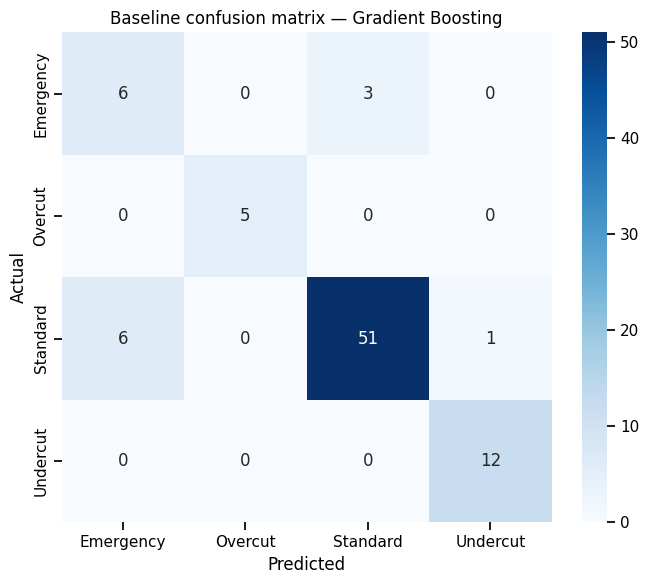

In [48]:
baseline_predictions = baseline_model.predict(X_test)
baseline_test_metrics = metric_row(y_test, baseline_predictions)

print("Baseline test metrics")
display(pd.DataFrame([baseline_test_metrics], index=[best_model_name]).round(4))

print("Per-class report")
report_df = pd.DataFrame(
    classification_report(y_test, baseline_predictions, output_dict=True, zero_division=0)
).T
display(report_df.round(4))

model_class_order = list(baseline_model.named_steps["model"].classes_)
cm = confusion_matrix(y_test, baseline_predictions, labels=model_class_order)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model_class_order, yticklabels=model_class_order)
plt.title(f"Baseline confusion matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

,feature,importance
11,num__laps_since_last_pit,0.26227
9,num__lap_time_delta,0.23837
15,num__approx_gap_ahead,0.14528
14,num__race_progress,0.08209
10,num__recent_pace_delta,0.06655
16,num__approx_gap_behind,0.05481
17,num__pressure_index,0.05144
13,num__laps_remaining,0.03345
3,num__pit_lap,0.01391
4,num__pit_lap_time_ms,0.00523


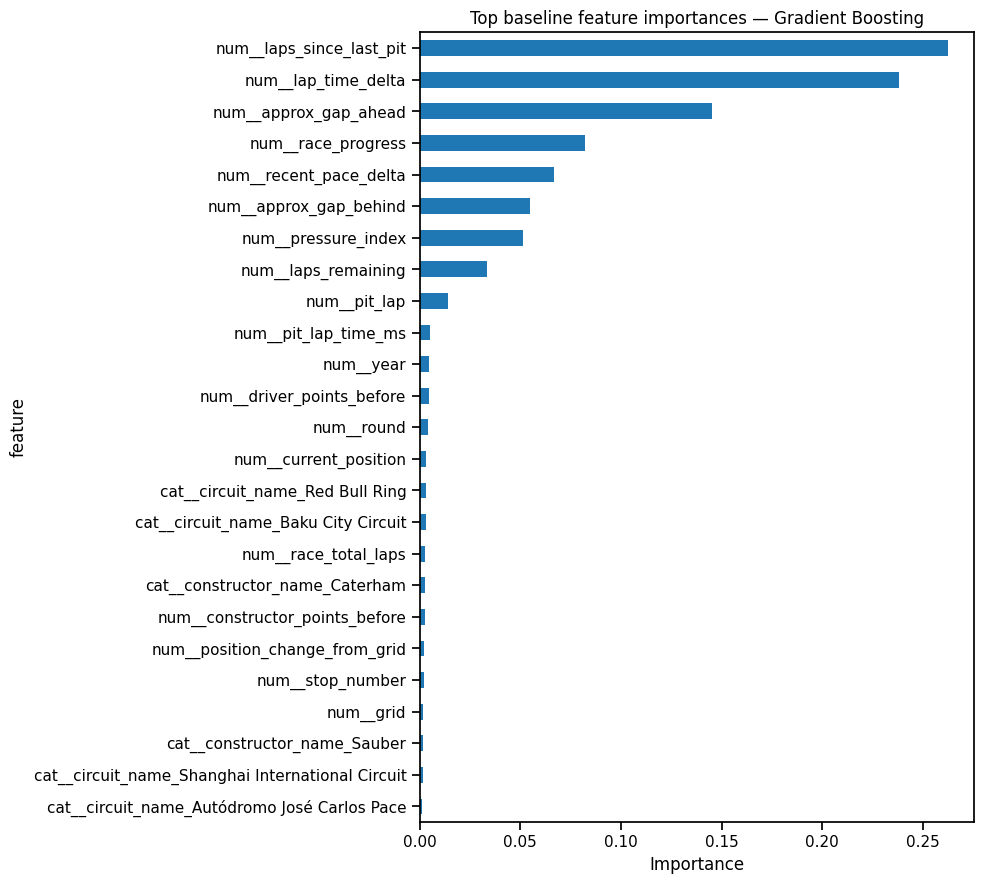

In [49]:
transformed_names = baseline_model.named_steps["preprocessor"].get_feature_names_out()
final_model = baseline_model.named_steps["model"]

if hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
elif hasattr(final_model, "coef_"):
    importance_values = np.mean(np.abs(final_model.coef_), axis=0)
else:
    importance_values = np.zeros(len(transformed_names))

importance_df = (
    pd.DataFrame({"feature": transformed_names, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .head(25)
)
display(importance_df.round(5))

importance_df.sort_values("importance").plot(
    kind="barh", x="feature", y="importance", legend=False, figsize=(10, 9)
)
plt.title(f"Top baseline feature importances — {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Semi-supervised learning: iterative pseudo labeling


In [50]:
def fit_selected_model(X_fit: pd.DataFrame, y_fit: pd.Series) -> Pipeline:
    return fit_named_model(best_model_name, X_fit, y_fit)


def run_pseudo_labeling(threshold: float):
    current_X = X_train.copy().reset_index(drop=True)
    current_y = y_train.copy().reset_index(drop=True)
    pool_X = unlabeled_df[feature_columns].copy().reset_index(drop=True)

    model = fit_selected_model(current_X, current_y)
    initial_metrics = evaluate_estimator(model, X_test, y_test)
    history = [
        {
            "threshold": threshold,
            "round": 0,
            "pool_remaining": len(pool_X),
            "added_total": 0,
            "total_labeled": len(current_y),
            **{f"added_{c}": 0 for c in class_order},
            **initial_metrics,
        }
    ]

    best_model = model
    best_record = history[0].copy()

    for round_number in range(1, MAX_PSEUDO_ROUNDS + 1):
        probabilities = model.predict_proba(pool_X)
        confidences = probabilities.max(axis=1)
        predicted_labels = model.named_steps["model"].classes_[probabilities.argmax(axis=1)]

        candidate_indices = np.flatnonzero(confidences >= threshold)
        if len(candidate_indices) == 0:
            print(f"Threshold {threshold:.2f}: no candidates at round {round_number}.")
            break

        ranked = candidate_indices[np.argsort(confidences[candidate_indices])[::-1]]
        # Select every candidate that clears the confidence threshold this
        # round (per the assignment spec) rather than always truncating to a
        # fixed count -- a fixed per-round cap this large (800) was masking
        # any difference between thresholds, since >800 samples cleared even
        # the 0.85 bar every round.
        selected_indices = ranked
        selected_labels = predicted_labels[selected_indices]
        n_added = len(selected_indices)

        current_X = pd.concat(
            [current_X, pool_X.iloc[selected_indices]], ignore_index=True
        )
        current_y = pd.concat(
            [current_y, pd.Series(selected_labels, name="strategy")], ignore_index=True
        )

        keep_mask = np.ones(len(pool_X), dtype=bool)
        keep_mask[selected_indices] = False
        pool_X = pool_X.loc[keep_mask].reset_index(drop=True)

        model = fit_selected_model(current_X, current_y)
        metrics = evaluate_estimator(model, X_test, y_test)
        additions = Counter(selected_labels)
        record = {
            "threshold": threshold,
            "round": round_number,
            "pool_remaining": len(pool_X),
            "added_total": n_added,
            "total_labeled": len(current_y),
            **{f"added_{c}": additions.get(c, 0) for c in class_order},
            **metrics,
        }
        history.append(record)

        if record["macro_f1"] > best_record["macro_f1"]:
            best_record = record.copy()
            best_model = model

        if n_added < 50:
            print(
                f"Threshold {threshold:.2f}: stopping after round {round_number}; "
                f"only {n_added} samples were added."
            )
            break

    return pd.DataFrame(history), best_model, best_record


pseudo_thresholds = [0.55, 0.60, 0.75, 0.85]
pseudo_histories = []
pseudo_best_by_threshold = {}

for threshold in pseudo_thresholds:
    print("\nRunning pseudo labeling at threshold", threshold)
    history, best_model_for_threshold, best_record_for_threshold = run_pseudo_labeling(threshold)
    pseudo_histories.append(history)
    pseudo_best_by_threshold[threshold] = {
        "model": best_model_for_threshold,
        "record": best_record_for_threshold,
    }

pseudo_results = pd.concat(pseudo_histories, ignore_index=True)
display(pseudo_results.round(4))

best_threshold = max(
    pseudo_best_by_threshold,
    key=lambda t: pseudo_best_by_threshold[t]["record"]["macro_f1"],
)
pseudo_best_model = pseudo_best_by_threshold[best_threshold]["model"]
pseudo_best_record = pseudo_best_by_threshold[best_threshold]["record"]

print("Best pseudo-labeling threshold:", best_threshold)
print("Best pseudo-labeling record:")
display(pd.DataFrame([pseudo_best_record]).round(4))


Running pseudo labeling at threshold 0.55
Threshold 0.55: stopping after round 3; only 13 samples were added.

Running pseudo labeling at threshold 0.6
Threshold 0.60: stopping after round 3; only 28 samples were added.

Running pseudo labeling at threshold 0.75
Threshold 0.75: stopping after round 5; only 26 samples were added.

Running pseudo labeling at threshold 0.85
Threshold 0.85: stopping after round 5; only 43 samples were added.


,threshold,round,pool_remaining,added_total,total_labeled,added_Standard,added_Undercut,added_Emergency,added_Overcut,accuracy,macro_precision,macro_recall,macro_f1
0,0.55,0,7524,0,668,0,0,0,0,0.8810,0.8419,0.8865,0.8605
1,0.55,1,241,7283,7951,4911,1114,807,451,0.8333,0.7646,0.8927,0.8123
2,0.55,2,25,216,8167,39,70,61,46,0.8214,0.7519,0.8884,0.8017
3,0.55,3,12,13,8180,2,4,6,1,0.8095,0.7443,0.8841,0.7931
4,0.60,0,7524,0,668,0,0,0,0,0.8810,0.8419,0.8865,0.8605
5,0.60,1,410,7114,7782,4829,1087,778,420,0.8214,0.7519,0.8884,0.8017
6,0.60,2,74,336,8118,58,96,99,83,0.8214,0.7519,0.8884,0.8017
7,0.60,3,46,28,8146,5,7,8,8,0.8214,0.7519,0.8884,0.8017
8,0.75,0,7524,0,668,0,0,0,0,0.8810,0.8419,0.8865,0.8605
9,0.75,1,1010,6514,7182,4527,968,664,355,0.8333,0.7587,0.8693,0.8035


Best pseudo-labeling threshold: 0.55
Best pseudo-labeling record:


,threshold,round,pool_remaining,added_total,total_labeled,added_Standard,added_Undercut,added_Emergency,added_Overcut,accuracy,macro_precision,macro_recall,macro_f1
0,0.55,0,7524,0,668,0,0,0,0,0.881,0.8419,0.8865,0.8605


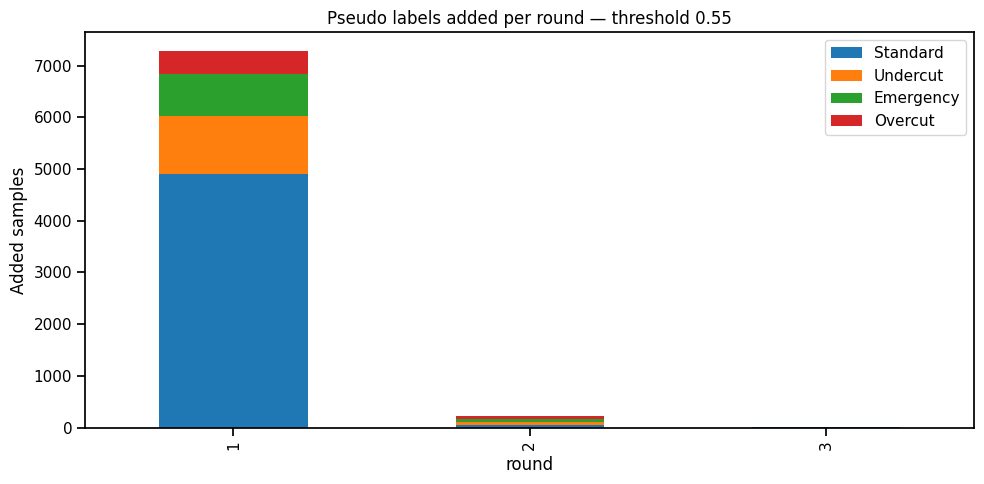

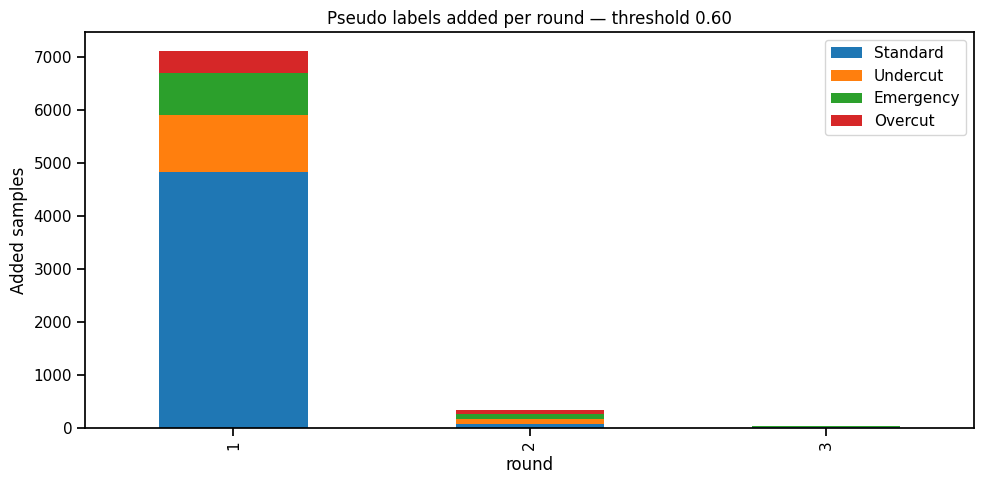

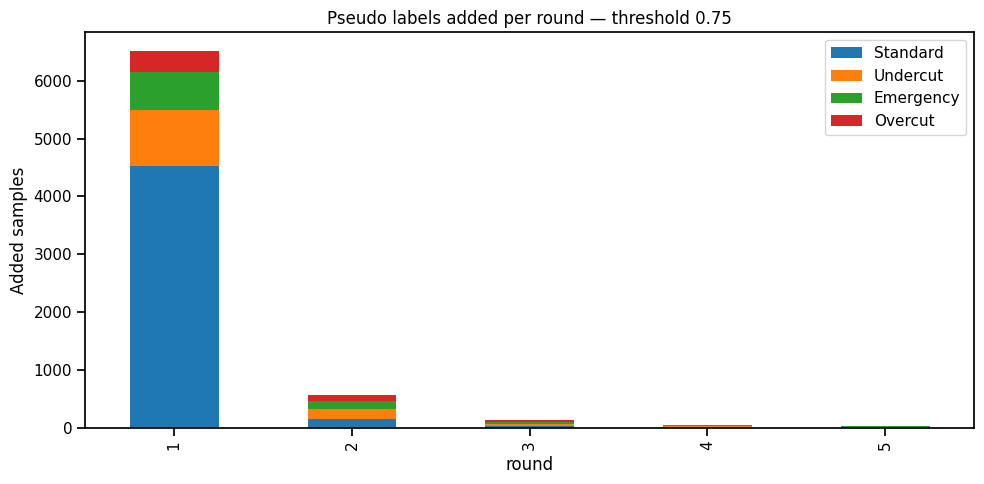

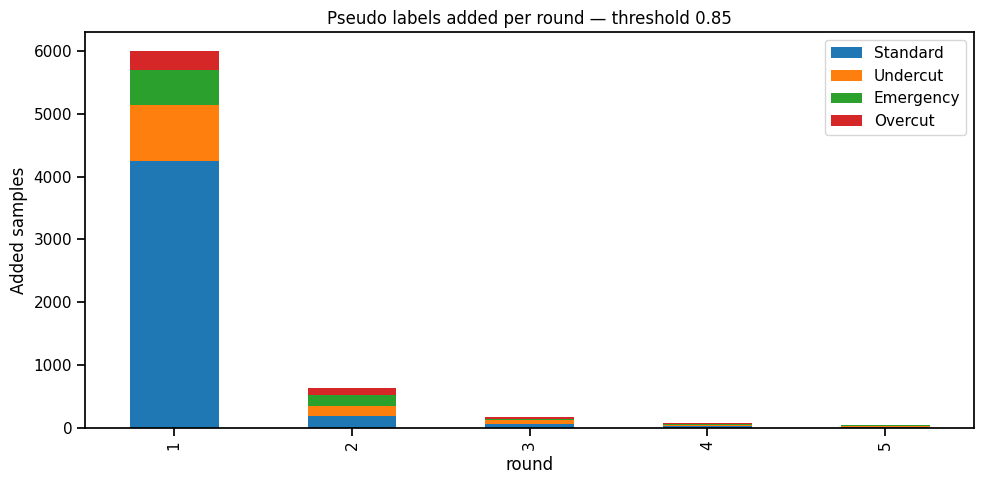

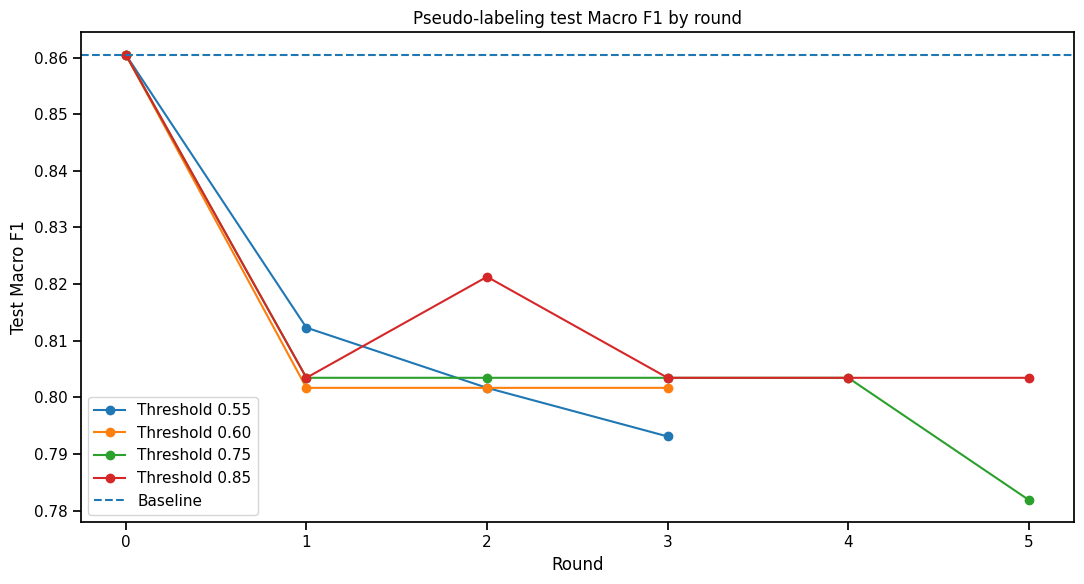

,threshold,round,total_labeled,macro_f1
0,0.55,0,668,0.8605
1,0.60,0,668,0.8605
2,0.75,0,668,0.8605
3,0.85,0,668,0.8605


In [51]:
for threshold in pseudo_thresholds:
    subset = pseudo_results[
        (pseudo_results["threshold"] == threshold) & (pseudo_results["round"] > 0)
    ].copy()
    if subset.empty:
        continue
    class_columns = [f"added_{c}" for c in class_order]
    plot_frame = subset.set_index("round")[class_columns]
    plot_frame.columns = [c.replace("added_", "") for c in plot_frame.columns]
    plot_frame.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title(f"Pseudo labels added per round — threshold {threshold:.2f}")
    plt.ylabel("Added samples")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(11, 6))
for threshold in pseudo_thresholds:
    subset = pseudo_results[pseudo_results["threshold"] == threshold]
    plt.plot(subset["round"], subset["macro_f1"], marker="o", label=f"Threshold {threshold:.2f}")
plt.axhline(baseline_test_metrics["macro_f1"], linestyle="--", label="Baseline")
plt.title("Pseudo-labeling test Macro F1 by round")
plt.xlabel("Round")
plt.ylabel("Test Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

pseudo_peak_table = (
    pseudo_results.sort_values("macro_f1", ascending=False)
    .groupby("threshold", as_index=False)
    .first()[["threshold", "round", "total_labeled", "macro_f1"]]
    .sort_values("macro_f1", ascending=False)
)
display(pseudo_peak_table.round(4))

## 11. Active learning


In [52]:
def uncertainty_scores(probabilities: np.ndarray, strategy: str) -> np.ndarray:
    if strategy == "least_confidence":
        return 1.0 - probabilities.max(axis=1)

    if strategy == "margin":
        sorted_probabilities = np.sort(probabilities, axis=1)
        margins = sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
        return 1.0 - margins

    if strategy == "entropy":
        safe_probabilities = np.clip(probabilities, 1e-12, 1.0)
        return -(safe_probabilities * np.log(safe_probabilities)).sum(axis=1)

    raise ValueError(f"Unknown query strategy: {strategy}")


def run_active_learning(query_strategy: str):
    current_X = X_train.copy().reset_index(drop=True)
    current_y = y_train.copy().reset_index(drop=True)
    pool_X = oracle_unlabeled_df[feature_columns].copy().reset_index(drop=True)
    pool_y = oracle_unlabeled_df["strategy"].copy().reset_index(drop=True)

    model = fit_selected_model(current_X, current_y)
    history = [
        {
            "query_strategy": query_strategy,
            "round": 0,
            "queried_total": 0,
            "total_labeled": len(current_y),
            "pool_remaining": len(pool_X),
            **{f"queried_{c}": 0 for c in class_order},
            **evaluate_estimator(model, X_test, y_test),
        }
    ]

    best_model = model
    best_record = history[0].copy()

    for round_number in range(1, ACTIVE_ROUNDS + 1):
        probabilities = model.predict_proba(pool_X)
        scores = uncertainty_scores(probabilities, query_strategy)
        k = min(ACTIVE_BATCH_SIZE, len(pool_X))
        selected_indices = np.argsort(scores)[-k:][::-1]

        selected_X = pool_X.iloc[selected_indices]
        selected_y = pool_y.iloc[selected_indices]

        current_X = pd.concat([current_X, selected_X], ignore_index=True)
        current_y = pd.concat([current_y, selected_y], ignore_index=True)

        keep_mask = np.ones(len(pool_X), dtype=bool)
        keep_mask[selected_indices] = False
        pool_X = pool_X.loc[keep_mask].reset_index(drop=True)
        pool_y = pool_y.loc[keep_mask].reset_index(drop=True)

        model = fit_selected_model(current_X, current_y)
        metrics = evaluate_estimator(model, X_test, y_test)
        query_counts = Counter(selected_y)
        record = {
            "query_strategy": query_strategy,
            "round": round_number,
            "queried_total": k,
            "total_labeled": len(current_y),
            "pool_remaining": len(pool_X),
            **{f"queried_{c}": query_counts.get(c, 0) for c in class_order},
            **metrics,
        }
        history.append(record)

        if record["macro_f1"] > best_record["macro_f1"]:
            best_record = record.copy()
            best_model = model

    return pd.DataFrame(history), model, best_model, best_record


query_strategies = ["least_confidence", "margin", "entropy"]
active_histories = []
active_final_models = {}
active_best_artifacts = {}

for query_strategy in query_strategies:
    print("\nRunning active learning:", query_strategy)
    history, final_model, best_model_for_strategy, best_record_for_strategy = run_active_learning(
        query_strategy
    )
    active_histories.append(history)
    active_final_models[query_strategy] = final_model
    active_best_artifacts[query_strategy] = {
        "model": best_model_for_strategy,
        "record": best_record_for_strategy,
    }

active_results = pd.concat(active_histories, ignore_index=True)
display(active_results.round(4))

best_active_strategy = max(
    active_best_artifacts,
    key=lambda s: active_best_artifacts[s]["record"]["macro_f1"],
)
active_best_model = active_best_artifacts[best_active_strategy]["model"]
active_best_record = active_best_artifacts[best_active_strategy]["record"]

print("Best active-learning strategy:", best_active_strategy)
display(pd.DataFrame([active_best_record]).round(4))


Running active learning: least_confidence

Running active learning: margin

Running active learning: entropy


,query_strategy,round,queried_total,total_labeled,pool_remaining,queried_Standard,queried_Undercut,queried_Emergency,queried_Overcut,accuracy,macro_precision,macro_recall,macro_f1
0,least_confidence,0,0,668,7524,0,0,0,0,0.8810,0.8419,0.8865,0.8605
1,least_confidence,1,20,688,7504,8,3,8,1,0.8690,0.8251,0.8822,0.8489
2,least_confidence,2,20,708,7484,12,4,3,1,0.8571,0.8235,0.8779,0.8432
3,least_confidence,3,20,728,7464,9,6,1,4,0.8690,0.8376,0.9057,0.8606
4,least_confidence,4,20,748,7444,11,1,5,3,0.8452,0.8161,0.8736,0.8352
5,least_confidence,5,20,768,7424,12,1,4,3,0.8452,0.8161,0.8736,0.8352
6,least_confidence,6,20,788,7404,13,4,3,0,0.8333,0.8095,0.8693,0.8276
7,least_confidence,7,20,808,7384,10,5,2,3,0.8929,0.8592,0.9377,0.8860
8,least_confidence,8,20,828,7364,9,4,4,3,0.8929,0.8656,0.9143,0.8819
9,margin,0,0,668,7524,0,0,0,0,0.8810,0.8419,0.8865,0.8605


Best active-learning strategy: margin


,query_strategy,round,queried_total,total_labeled,pool_remaining,queried_Standard,queried_Undercut,queried_Emergency,queried_Overcut,accuracy,macro_precision,macro_recall,macro_f1
0,margin,7,20,808,7384,17,3,0,0,0.9167,0.8808,0.9229,0.8995


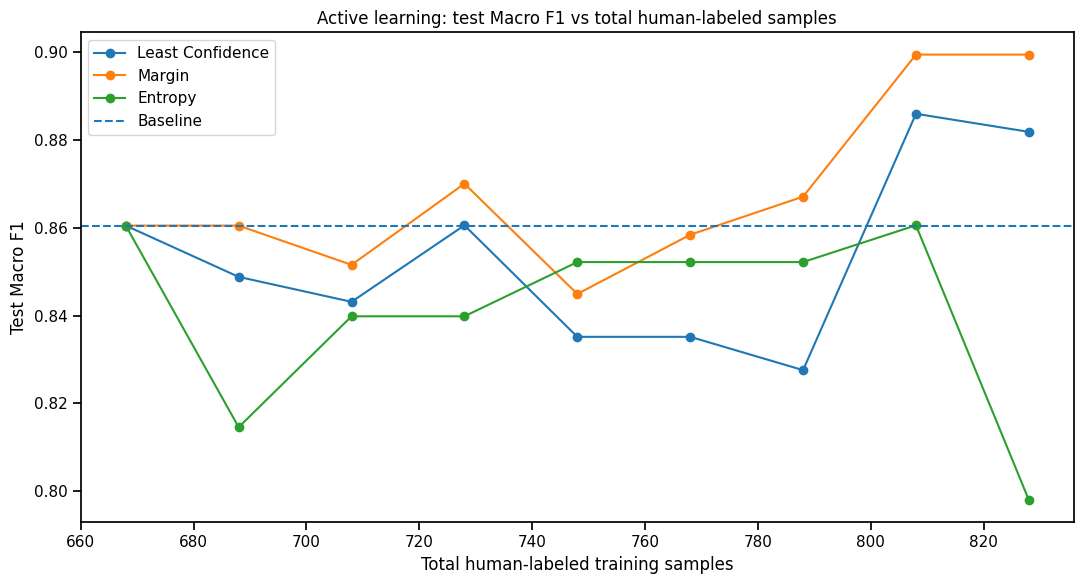

,query_strategy,queried_Standard,queried_Undercut,queried_Emergency,queried_Overcut
1,least_confidence,8,3,8,1
10,margin,12,6,2,0
19,entropy,9,3,6,2


,query_strategy,first_matching_round,total_labeled
0,least_confidence,3,728
1,margin,1,688
2,entropy,7,808


In [53]:
plt.figure(figsize=(11, 6))
for query_strategy in query_strategies:
    subset = active_results[active_results["query_strategy"] == query_strategy]
    plt.plot(
        subset["total_labeled"],
        subset["macro_f1"],
        marker="o",
        label=query_strategy.replace("_", " ").title(),
    )
plt.axhline(baseline_test_metrics["macro_f1"], linestyle="--", label="Baseline")
plt.title("Active learning: test Macro F1 vs total human-labeled samples")
plt.xlabel("Total human-labeled training samples")
plt.ylabel("Test Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

round_one_columns = ["query_strategy"] + [f"queried_{c}" for c in class_order]
round_one_mix = active_results[active_results["round"] == 1][round_one_columns].copy()
display(round_one_mix)

match_rows = []
for query_strategy in query_strategies:
    subset = active_results[
        (active_results["query_strategy"] == query_strategy)
        & (active_results["round"] > 0)
        & (active_results["macro_f1"] >= baseline_test_metrics["macro_f1"])
    ]
    if subset.empty:
        match_rows.append(
            {
                "query_strategy": query_strategy,
                "first_matching_round": np.nan,
                "total_labeled": np.nan,
            }
        )
    else:
        first = subset.sort_values("round").iloc[0]
        match_rows.append(
            {
                "query_strategy": query_strategy,
                "first_matching_round": int(first["round"]),
                "total_labeled": int(first["total_labeled"]),
            }
        )

baseline_match_table = pd.DataFrame(match_rows)
display(baseline_match_table)

## 12. Comparative analysis

In [54]:
summary_rows = [
    {
        "method": f"Baseline — {best_model_name}",
        "total_labeled_samples": len(y_train),
        **baseline_test_metrics,
    }
]

best_pl_history = pseudo_results[pseudo_results["threshold"] == best_threshold].sort_values("round")
for _, row in best_pl_history[best_pl_history["round"] > 0].iterrows():
    summary_rows.append(
        {
            "method": f"Pseudo Labeling t={best_threshold:.2f} Round {int(row['round'])}",
            "total_labeled_samples": int(row["total_labeled"]),
            "accuracy": row["accuracy"],
            "macro_precision": row["macro_precision"],
            "macro_recall": row["macro_recall"],
            "macro_f1": row["macro_f1"],
        }
    )

for query_strategy in query_strategies:
    final_row = (
        active_results[active_results["query_strategy"] == query_strategy]
        .sort_values("round")
        .iloc[-1]
    )
    summary_rows.append(
        {
            "method": f"Active Learning — {query_strategy.replace('_', ' ').title()} Final",
            "total_labeled_samples": int(final_row["total_labeled"]),
            "accuracy": final_row["accuracy"],
            "macro_precision": final_row["macro_precision"],
            "macro_recall": final_row["macro_recall"],
            "macro_f1": final_row["macro_f1"],
        }
    )

summary_table = pd.DataFrame(summary_rows)
display(summary_table.round(4))

,method,total_labeled_samples,accuracy,macro_precision,macro_recall,macro_f1
0,Baseline — Gradient Boosting,668,0.8810,0.8419,0.8865,0.8605
1,Pseudo Labeling t=0.55 Round 1,7951,0.8333,0.7646,0.8927,0.8123
2,Pseudo Labeling t=0.55 Round 2,8167,0.8214,0.7519,0.8884,0.8017
3,Pseudo Labeling t=0.55 Round 3,8180,0.8095,0.7443,0.8841,0.7931
4,Active Learning — Least Confidence Final,828,0.8929,0.8656,0.9143,0.8819
5,Active Learning — Margin Final,828,0.9167,0.8808,0.9229,0.8995
6,Active Learning — Entropy Final,828,0.8214,0.7573,0.8649,0.7980


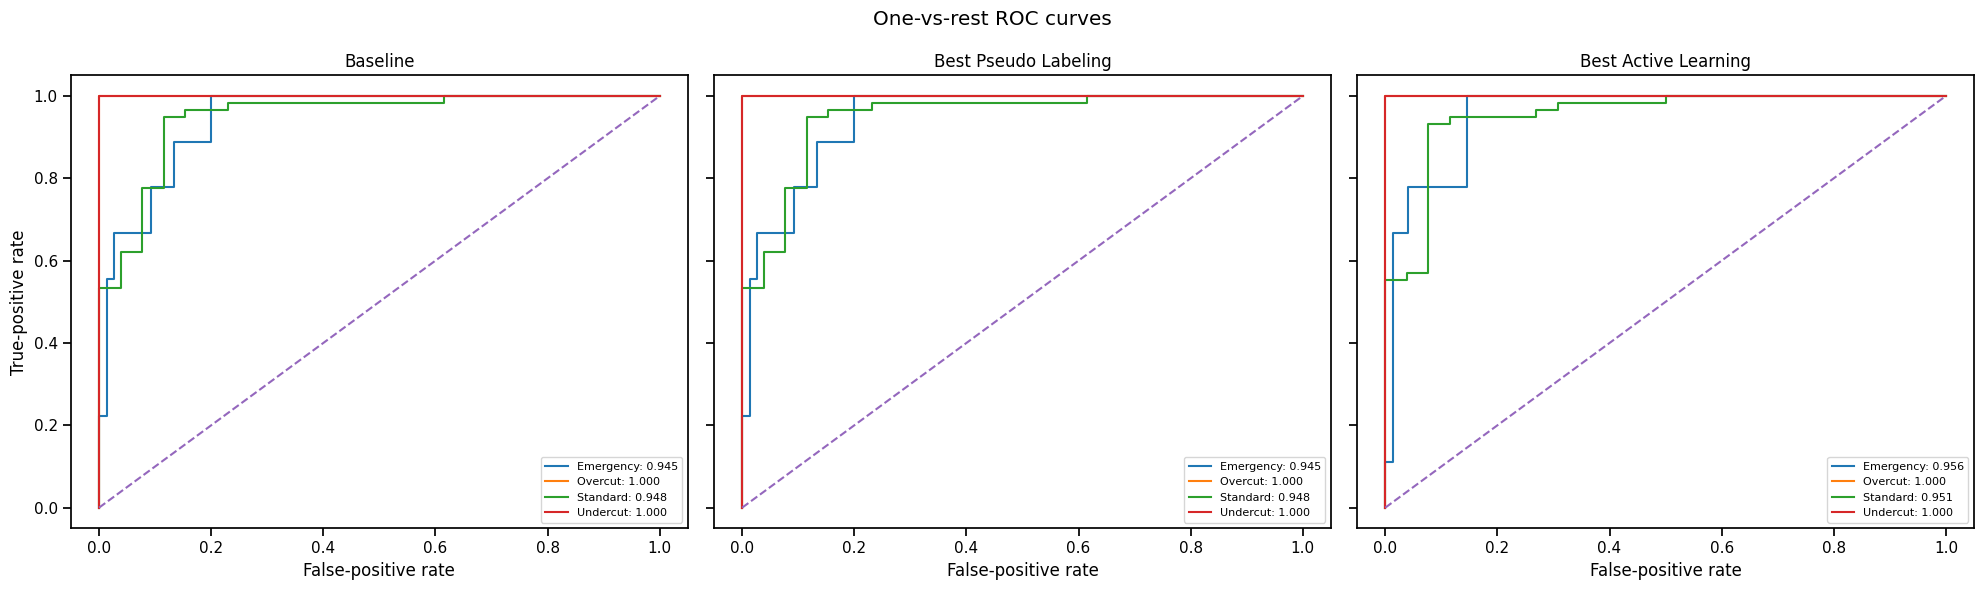

method,Baseline,Best Active Learning,Best Pseudo Labeling
class,,,
Emergency,0.9452,0.9556,0.9452
Mean,0.9732,0.9766,0.9732
Overcut,1.0000,1.0000,1.0000
Standard,0.9476,0.9509,0.9476
Undercut,1.0000,1.0000,1.0000


Lowest average AUC class: Emergency
Full-pool label count: 836


In [55]:
roc_models = {
    "Baseline": baseline_model,
    "Best Pseudo Labeling": pseudo_best_model,
    "Best Active Learning": active_best_model,
}

roc_class_order = sorted(y_train.unique())
y_test_binary = label_binarize(y_test, classes=roc_class_order)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
auc_rows = []

for ax, (method_name, estimator) in zip(axes, roc_models.items()):
    probabilities = estimator.predict_proba(X_test)
    estimator_classes = list(estimator.named_steps["model"].classes_)
    reorder = [estimator_classes.index(c) for c in roc_class_order]
    probabilities = probabilities[:, reorder]

    method_aucs = []
    for class_index, class_name in enumerate(roc_class_order):
        fpr, tpr, _ = roc_curve(y_test_binary[:, class_index], probabilities[:, class_index])
        class_auc = auc(fpr, tpr)
        method_aucs.append(class_auc)
        auc_rows.append(
            {
                "method": method_name,
                "class": class_name,
                "AUC": class_auc,
            }
        )
        ax.plot(fpr, tpr, label=f"{class_name}: {class_auc:.3f}")

    auc_rows.append(
        {
            "method": method_name,
            "class": "Mean",
            "AUC": float(np.mean(method_aucs)),
        }
    )
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(method_name)
    ax.set_xlabel("False-positive rate")
    ax.legend(fontsize=8)

axes[0].set_ylabel("True-positive rate")
plt.suptitle("One-vs-rest ROC curves")
plt.tight_layout()
plt.show()

auc_table = pd.DataFrame(auc_rows)
display(auc_table.pivot(index="class", columns="method", values="AUC").round(4))

lowest_auc_class = (
    auc_table[auc_table["class"] != "Mean"]
    .groupby("class")["AUC"]
    .mean()
    .sort_values()
    .index[0]
)
print("Lowest average AUC class:", lowest_auc_class)
print("Full-pool label count:", int((full_labeled_df["strategy"] == lowest_auc_class).sum()))

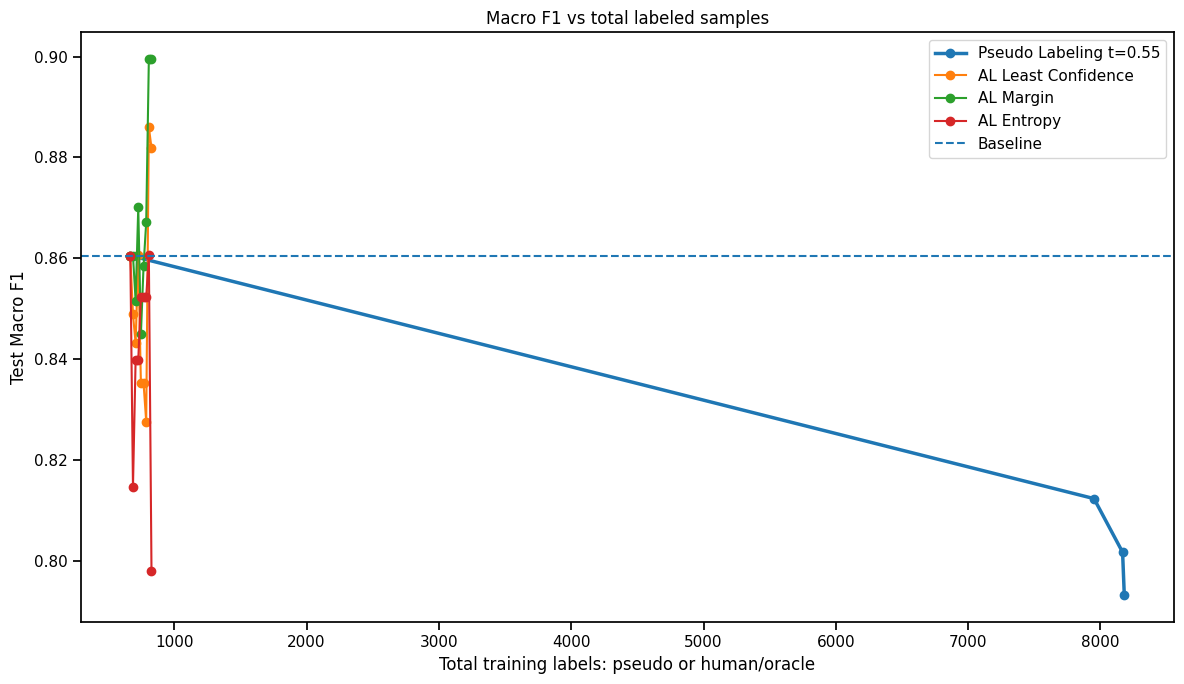

,common_target_macro_f1,pseudo_min_total_labels,active_min_total_labels
0,0.8605,668,668


In [56]:
plt.figure(figsize=(12, 7))

plt.plot(
    best_pl_history["total_labeled"],
    best_pl_history["macro_f1"],
    marker="o",
    linewidth=2.5,
    label=f"Pseudo Labeling t={best_threshold:.2f}",
)

for query_strategy in query_strategies:
    subset = active_results[active_results["query_strategy"] == query_strategy]
    plt.plot(
        subset["total_labeled"],
        subset["macro_f1"],
        marker="o",
        label=f"AL {query_strategy.replace('_', ' ').title()}",
    )

plt.axhline(baseline_test_metrics["macro_f1"], linestyle="--", label="Baseline")
plt.title("Macro F1 vs total labeled samples")
plt.xlabel("Total training labels: pseudo or human/oracle")
plt.ylabel("Test Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

best_pl_f1 = best_pl_history["macro_f1"].max()
best_al_f1 = active_results["macro_f1"].max()
common_target_f1 = min(best_pl_f1, best_al_f1)

pl_reach = best_pl_history[best_pl_history["macro_f1"] >= common_target_f1]
al_reach = active_results[active_results["macro_f1"] >= common_target_f1]

sample_efficiency = {
    "common_target_macro_f1": common_target_f1,
    "pseudo_min_total_labels": (
        int(pl_reach["total_labeled"].min()) if not pl_reach.empty else np.nan
    ),
    "active_min_total_labels": (
        int(al_reach["total_labeled"].min()) if not al_reach.empty else np.nan
    ),
}
display(pd.DataFrame([sample_efficiency]).round(4))

In [57]:
def detect_plateau(history: pd.DataFrame, tolerance: float = 0.005, patience: int = 2):
    ordered = history.sort_values("round").reset_index(drop=True)
    improvements = ordered["macro_f1"].diff().fillna(np.inf)
    for idx in range(patience, len(ordered)):
        recent = improvements.iloc[idx - patience + 1 : idx + 1].abs()
        if (recent < tolerance).all():
            return {
                "round": int(ordered.loc[idx, "round"]),
                "total_labeled": int(ordered.loc[idx, "total_labeled"]),
                "macro_f1": float(ordered.loc[idx, "macro_f1"]),
                "plateaued": True,
            }
    # No round satisfied the plateau criterion -- report the final round
    # instead of leaving this blank, and flag that it did not plateau.
    last = ordered.iloc[-1]
    return {
        "round": int(last["round"]),
        "total_labeled": int(last["total_labeled"]),
        "macro_f1": float(last["macro_f1"]),
        "plateaued": False,
    }

plateau_rows = []
pl_plateau = detect_plateau(best_pl_history)
plateau_rows.append({"method": f"Pseudo t={best_threshold:.2f}", **(pl_plateau or {})})

for query_strategy in query_strategies:
    subset = active_results[active_results["query_strategy"] == query_strategy]
    plateau = detect_plateau(subset)
    plateau_rows.append(
        {"method": f"AL {query_strategy.replace('_', ' ').title()}", **(plateau or {})}
    )

plateau_table = pd.DataFrame(plateau_rows)
display(plateau_table)

,method,round,total_labeled,macro_f1,plateaued
0,Pseudo t=0.55,3,8180,0.793097,False
1,AL Least Confidence,8,828,0.881904,False
2,AL Margin,8,828,0.899513,False
3,AL Entropy,6,788,0.852222,True


## 13. Save experiment outputs

In [58]:
labeled_df.to_csv(OUTPUT_DIR / "labeled.csv", index=False)
unlabeled_df.to_csv(OUTPUT_DIR / "unlabeled.csv", index=False)

validation_results.to_csv(OUTPUT_DIR / "baseline_validation_results.csv", index=False)
pd.DataFrame([baseline_test_metrics]).to_csv(
    OUTPUT_DIR / "baseline_test_metrics.csv", index=False
)
ks_results.to_csv(OUTPUT_DIR / "ks_split_quality.csv", index=False)
pseudo_results.to_csv(OUTPUT_DIR / "pseudo_labeling_history.csv", index=False)
active_results.to_csv(OUTPUT_DIR / "active_learning_history.csv", index=False)
summary_table.to_csv(OUTPUT_DIR / "comparative_summary.csv", index=False)
auc_table.to_csv(OUTPUT_DIR / "roc_auc_results.csv", index=False)
plateau_table.to_csv(OUTPUT_DIR / "plateau_summary.csv", index=False)

output_files = sorted(p.name for p in OUTPUT_DIR.glob("*.csv"))
print("Generated CSV files:")
for filename in output_files:
    print(" -", filename)

Generated CSV files:
 - active_learning_history.csv
 - baseline_test_metrics.csv
 - baseline_validation_results.csv
 - comparative_summary.csv
 - ks_split_quality.csv
 - labeled.csv
 - plateau_summary.csv
 - pseudo_labeling_history.csv
 - roc_auc_results.csv
 - unlabeled.csv
